In [56]:
# Preparetion du dataset 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SPP = pd.read_csv("../data/SPP.csv")

## Mise à jour V2 — corrections de sélection de variables

- Remplacement de la cellule de permutation importance par une validation croisée `StratifiedKFold` (strates construites à partir de quantiles de la cible), un pipeline sklearn complet et `cross_validate`.
- Utilisation d'un `ExtraTreesRegressor` configuré avec `max_depth=10` et `min_samples_leaf=5`, en s'appuyant sur le préprocesseur déjà entraîné et sans clonage explicite dans une boucle.
- Ajout d'une cellule finale qui combine les importances par impureté et par permutation : top 10 dans les deux méthodes ou importance supérieure à 1 % dans au moins une méthode, avec exclusion de variables métier redondantes telles que `Region` et `Language_Section`.
- Export de la liste retenue dans `final_features_list.csv`.


In [57]:
TARGET = "Exam_Score"

In [58]:
# 1. Nombre de lignes et de colonnes 
print(SPP.shape)

(6607, 21)


In [59]:
print(SPP["Hours_Studied"].describe())

count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64


In [60]:
# 2. Noms de colonnes 
print(SPP.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'School_Type', 'Physical_Activity', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Electricity_Access', 'Region', 'Transport_Mode', 'Class_Size', 'Language_Section']


In [61]:
print(SPP.dtypes)

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
School_Type                     str
Physical_Activity             int64
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
Electricity_Access              str
Region                          str
Transport_Mode                  str
Class_Size                    int64
Language_Section                str
dtype: object


In [62]:
# 4. Valeurs manquantes 
print(SPP.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
School_Type                    0
Physical_Activity              0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
Electricity_Access             0
Region                         0
Transport_Mode                 0
Class_Size                     0
Language_Section               0
dtype: int64


In [63]:
# 5. Doublons
print(SPP.duplicated().sum())

0


In [64]:
# 6. Separation des categorielles des numeriques
numeric_columns_eda = SPP.select_dtypes(include=np.number).columns.tolist()

categorical_columns_eda = SPP.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numériques :")
print(numeric_columns_eda)

print("\nVariables catégorielles :")
print(categorical_columns_eda)

Variables numériques :
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score', 'Class_Size']

Variables catégorielles :
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access', 'Family_Income', 'School_Type', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Electricity_Access', 'Region', 'Transport_Mode', 'Language_Section']


In [65]:
# 7, Min max
for col in numeric_columns_eda:
    print(
        f"{col} : min = {SPP[col].min()}, "
        f"max = {SPP[col].max()}"
    )

Hours_Studied : min = 1, max = 44
Attendance : min = 60, max = 100
Sleep_Hours : min = 4, max = 10
Previous_Scores : min = 50, max = 100
Tutoring_Sessions : min = 0, max = 8
Physical_Activity : min = 0, max = 6
Exam_Score : min = 55, max = 101
Class_Size : min = 20, max = 199


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


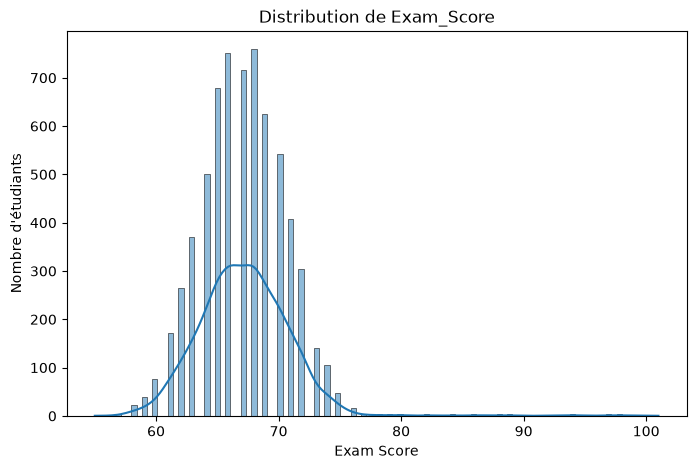

In [66]:
# 8. Distribution de la target
print(SPP[TARGET].describe())

plt.figure(figsize=(8, 5))

sns.histplot(SPP[TARGET], kde=True)

plt.title("Distribution de Exam_Score")
plt.xlabel("Exam Score")
plt.ylabel("Nombre d'étudiants")

plt.show()

In [67]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n--- {column} ---")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Limite basse : {lower_bound}")
    print(f"Limite haute : {upper_bound}")
    print(f"Nombre d'outliers : {len(outliers)}")

    print("\nValeurs des outliers :")
    print(outliers[column].value_counts().sort_index())

    return outliers

detect_outliers_iqr(SPP, "Hours_Studied")


--- Hours_Studied ---
Q1 : 16.0
Q3 : 24.0
IQR : 8.0
Limite basse : 4.0
Limite haute : 36.0
Nombre d'outliers : 43

Valeurs des outliers :
Hours_Studied
1      3
2      6
3     12
37     6
38     7
39     7
43     1
44     1
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Internet_Access,Tutoring_Sessions,Family_Income,...,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Electricity_Access,Region,Transport_Mode,Class_Size,Language_Section
209,43,86,High,Medium,Yes,7,97,Yes,2,Medium,...,1,High School,Near,Female,78,sometimes,Adamawa,Walk,43,Anglophone
262,1,69,High,Medium,Yes,6,97,Yes,1,Low,...,3,High School,Near,Female,61,sometimes,North West,Private car,112,Francophone
478,38,86,Low,High,Yes,7,79,Yes,3,Low,...,3,High School,Near,Male,73,yes,Littoral,Private car,104,Bilingual
1061,3,85,Low,High,No,8,73,Yes,2,Low,...,3,High School,Near,Male,62,sometimes,North,Taxi,158,Anglophone
1101,3,62,Medium,Low,No,6,67,Yes,1,Low,...,3,High School,Near,Male,55,no,Centre,Walk,23,Anglophone
1539,3,96,High,High,Yes,9,59,Yes,2,Low,...,3,College,Moderate,Female,66,yes,North,Walk,195,Bilingual
1591,2,84,Low,High,No,8,54,Yes,3,Low,...,4,NaN,Near,Male,62,yes,West,Walk,58,Anglophone
1615,39,95,Medium,High,Yes,9,54,Yes,2,Medium,...,3,High School,Moderate,Male,77,no,East,Bike,122,Francophone
1957,39,97,High,High,Yes,10,91,Yes,2,Low,...,3,High School,Moderate,Female,79,yes,South West,Bike,131,Bilingual
1971,2,96,Low,High,Yes,9,77,Yes,3,Medium,...,2,High School,Far,Female,65,yes,East,Walk,170,Bilingual


In [68]:

detect_outliers_iqr(SPP, "Tutoring_Sessions")


--- Tutoring_Sessions ---
Q1 : 1.0
Q3 : 2.0
IQR : 1.0
Limite basse : -0.5
Limite haute : 3.5
Nombre d'outliers : 430

Valeurs des outliers :
Tutoring_Sessions
4    301
5    103
6     18
7      7
8      1
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Internet_Access,Tutoring_Sessions,Family_Income,...,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Electricity_Access,Region,Transport_Mode,Class_Size,Language_Section
10,17,80,Low,High,No,8,88,No,4,Medium,...,4,College,Moderate,Male,68,yes,Adamawa,Taxi,186,Anglophone
76,21,77,Low,Medium,Yes,7,90,Yes,4,Medium,...,3,Postgraduate,Moderate,Male,68,no,North West,Bike,94,Francophone
82,29,78,High,High,Yes,4,93,Yes,5,Medium,...,3,College,Near,Male,74,yes,North,Private car,113,Bilingual
124,24,73,Medium,High,Yes,8,64,Yes,4,High,...,3,College,Moderate,Male,68,yes,Adamawa,Bike,145,Francophone
129,17,94,Low,Medium,Yes,8,65,Yes,4,Medium,...,6,High School,Far,Female,68,no,South,Bike,181,Bilingual
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6552,22,65,Low,Medium,No,8,98,Yes,4,Medium,...,3,High School,Near,Female,66,yes,Adamawa,Bus,112,Anglophone
6553,16,74,Low,High,No,8,76,Yes,5,Low,...,3,College,Moderate,Male,65,sometimes,Littoral,Walk,119,Bilingual
6559,28,72,Low,Medium,Yes,7,60,Yes,4,High,...,3,Postgraduate,Near,Male,69,yes,Littoral,Walk,175,Bilingual
6579,9,84,Medium,Medium,No,6,74,Yes,5,High,...,2,High School,Near,Male,67,no,East,Walk,95,Anglophone


In [69]:

detect_outliers_iqr(SPP, "Exam_Score")


--- Exam_Score ---
Q1 : 65.0
Q3 : 69.0
IQR : 4.0
Limite basse : 59.0
Limite haute : 75.0
Nombre d'outliers : 104

Valeurs des outliers :
Exam_Score
55      1
56      1
57      4
58     22
76     16
77      5
78      4
79      3
80      5
82      4
83      1
84      3
85      1
86      4
87      2
88      3
89      3
91      1
92      2
93      2
94      4
95      2
96      1
97      3
98      3
99      2
100     1
101     1
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Internet_Access,Tutoring_Sessions,Family_Income,...,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Electricity_Access,Region,Transport_Mode,Class_Size,Language_Section
94,18,89,High,Medium,Yes,4,73,Yes,3,High,...,2,College,Near,Female,100,sometimes,Centre,Bus,146,Bilingual
106,31,100,Medium,Medium,No,7,59,Yes,2,High,...,5,Postgraduate,Moderate,Male,76,sometimes,Littoral,Private car,58,Francophone
113,35,99,High,High,Yes,7,85,Yes,2,Medium,...,2,Postgraduate,Near,Female,79,no,Littoral,Private car,175,Anglophone
209,43,86,High,Medium,Yes,7,97,Yes,2,Medium,...,1,High School,Near,Female,78,sometimes,Adamawa,Walk,43,Anglophone
217,19,70,Medium,Low,No,7,54,Yes,0,Medium,...,2,High School,Moderate,Male,89,sometimes,Far North,Bus,182,Francophone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6347,28,96,High,Low,Yes,4,98,Yes,1,High,...,3,High School,Near,Male,98,yes,North West,Walk,74,Bilingual
6393,16,83,Low,Medium,Yes,8,92,Yes,2,High,...,4,Postgraduate,Near,Female,98,yes,Centre,Bike,98,Anglophone
6431,4,60,Medium,Medium,Yes,7,55,Yes,2,Low,...,2,Postgraduate,Near,Male,58,no,East,Bike,185,Anglophone
6522,18,90,High,High,Yes,6,54,Yes,1,Medium,...,3,High School,Near,Female,95,yes,West,Private car,110,Francophone


In [70]:
# Correction : liste explicite des colonnes à visualiser pour les outliers
# (cellule ajoutée : la cellule existante de vérification l’utilise).
cols_outliers = [
    col for col in ["Hours_Studied", "Tutoring_Sessions", "Exam_Score"]
    if col in SPP.columns
]
if not cols_outliers:
    raise ValueError("Aucune colonne d’outlier attendue n’est présente dans SPP.")
print("Colonnes d’outliers :", cols_outliers)


Colonnes d’outliers : ['Hours_Studied', 'Tutoring_Sessions', 'Exam_Score']


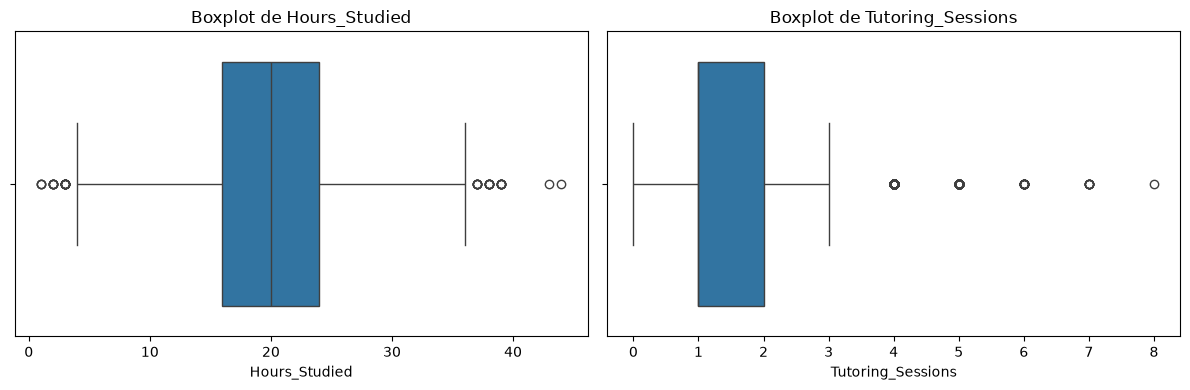

In [71]:
# verification visuelle
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, cols_outliers):
    sns.boxplot(x=SPP[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

/tmp/ipykernel_41626/1559427322.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


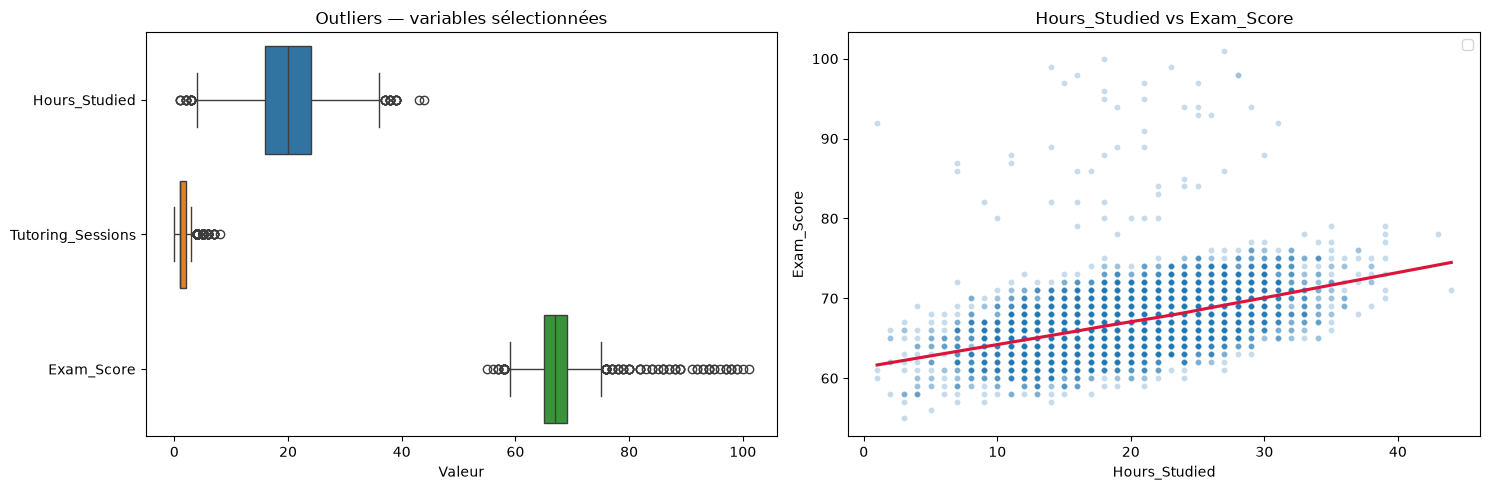

In [72]:
# Visualisation ajoutée : outliers et relation Hours_Studied / Exam_Score
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=SPP[cols_outliers], orient="h", ax=axes[0])
axes[0].set_title("Outliers — variables sélectionnées")
axes[0].set_xlabel("Valeur")
sns.scatterplot(data=SPP, x="Hours_Studied", y=TARGET, alpha=0.25, s=18, ax=axes[1])
sns.regplot(data=SPP, x="Hours_Studied", y=TARGET, scatter=False, lowess=True,
            color="crimson", line_kws={"label": "Tendance LOWESS"}, ax=axes[1])
axes[1].set_title("Hours_Studied vs Exam_Score")
axes[1].legend()
plt.tight_layout()
plt.show()


In [73]:
# 10. Cardinalite des variables categorielles
for col in categorical_columns_eda:
    print(f"\n\n{col}")
    print("Cardinalité :", SPP[col].nunique())
    print(SPP[col].value_counts())



Parental_Involvement
Cardinalité : 3
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64


Access_to_Resources
Cardinalité : 3
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


Extracurricular_Activities
Cardinalité : 2
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64


Internet_Access
Cardinalité : 2
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64


Family_Income
Cardinalité : 3
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


School_Type
Cardinalité : 2
School_Type
Public     4598
Private    2009
Name: count, dtype: int64


Parental_Education_Level
Cardinalité : 3
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64


Distance_from_Home
Cardinalité : 3
Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64


Gender
Ca

                   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
Hours_Studied           1.000000   -0.009908     0.010977         0.024846   
Attendance             -0.009908    1.000000    -0.015918        -0.020186   
Sleep_Hours             0.010977   -0.015918     1.000000        -0.021750   
Previous_Scores         0.024846   -0.020186    -0.021750         1.000000   
Tutoring_Sessions      -0.014282    0.014324    -0.012216        -0.013122   
Physical_Activity       0.004624   -0.022435    -0.000378        -0.011274   
Exam_Score              0.445455    0.581072    -0.017022         0.175079   
Class_Size             -0.010515    0.007599    -0.004143        -0.002751   

                   Tutoring_Sessions  Physical_Activity  Exam_Score  \
Hours_Studied              -0.014282           0.004624    0.445455   
Attendance                  0.014324          -0.022435    0.581072   
Sleep_Hours                -0.012216          -0.000378   -0.017022   
Previous_Scor

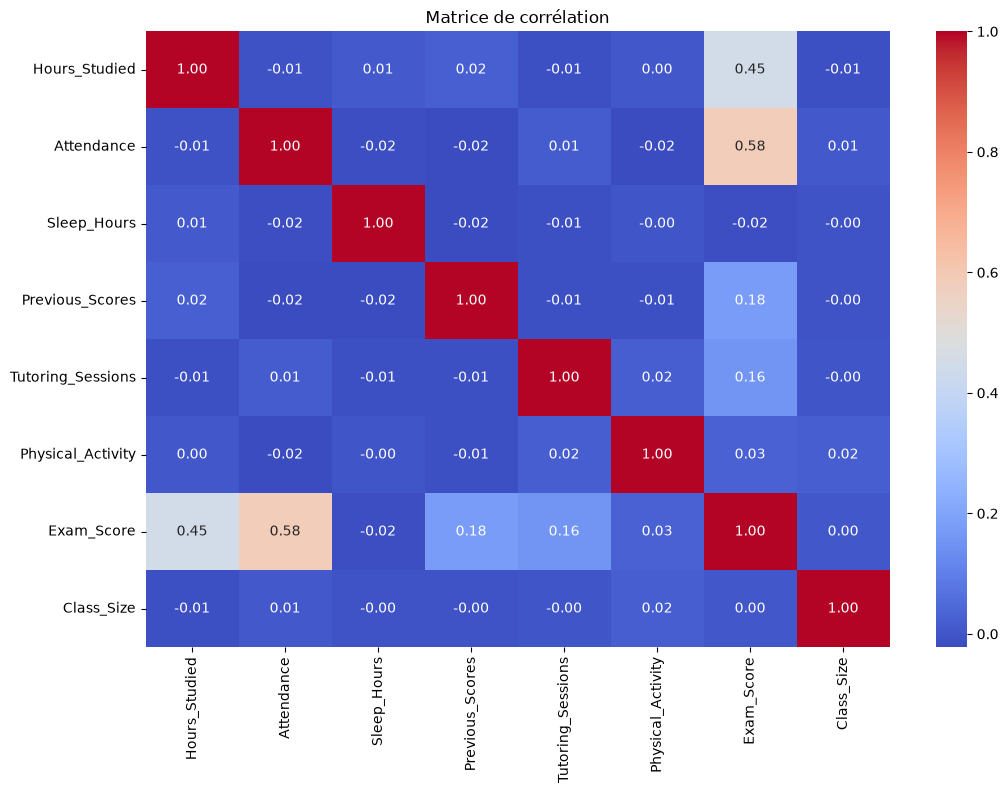

In [74]:
# 11. Matrice de correlation
correlation_matrix = SPP[numeric_columns_eda].corr()

print(correlation_matrix)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

Variables catégorielles de faible cardinalité : ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access', 'Family_Income', 'School_Type', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Electricity_Access', 'Region', 'Transport_Mode', 'Language_Section']


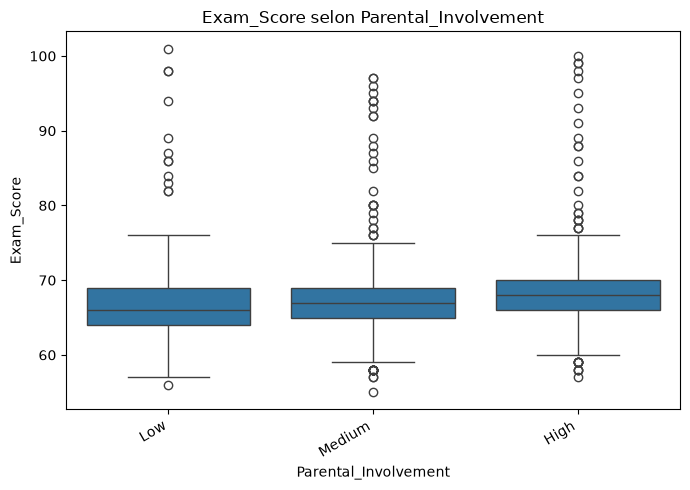

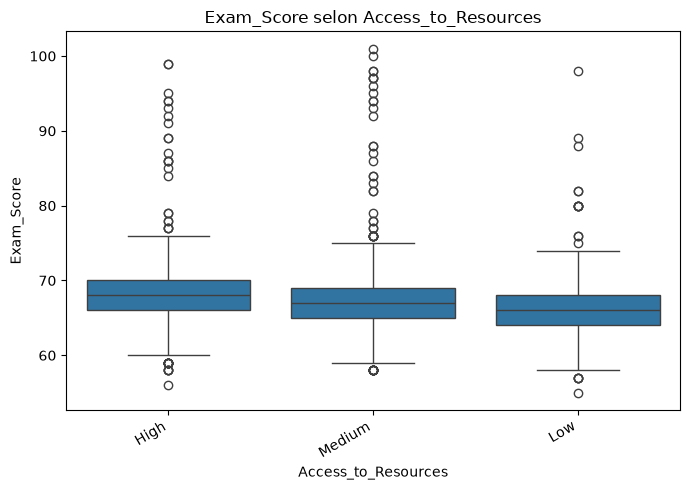

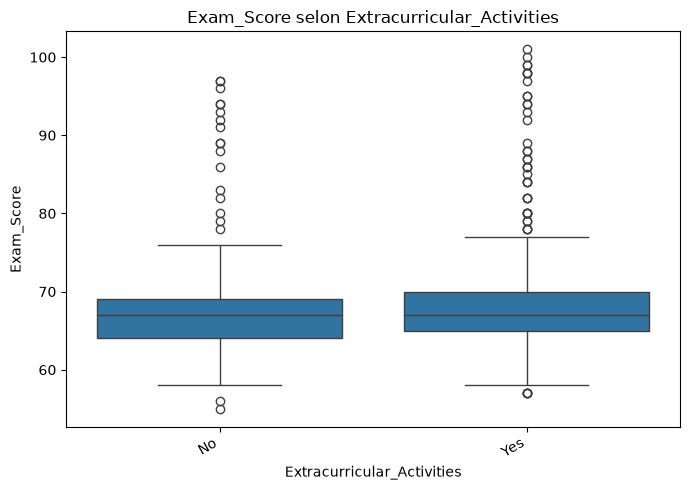

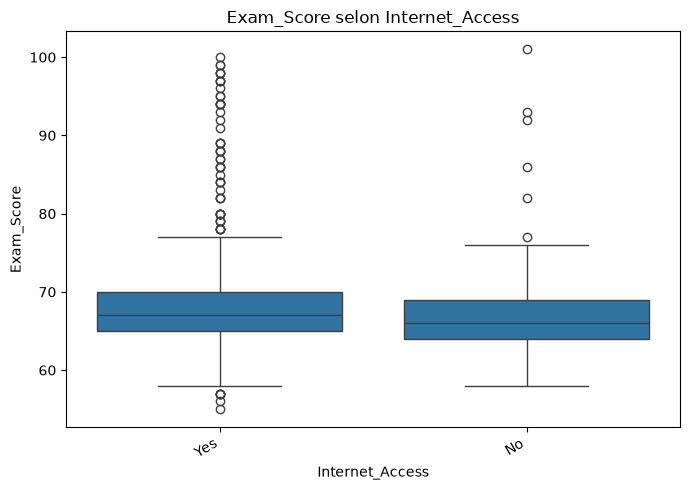

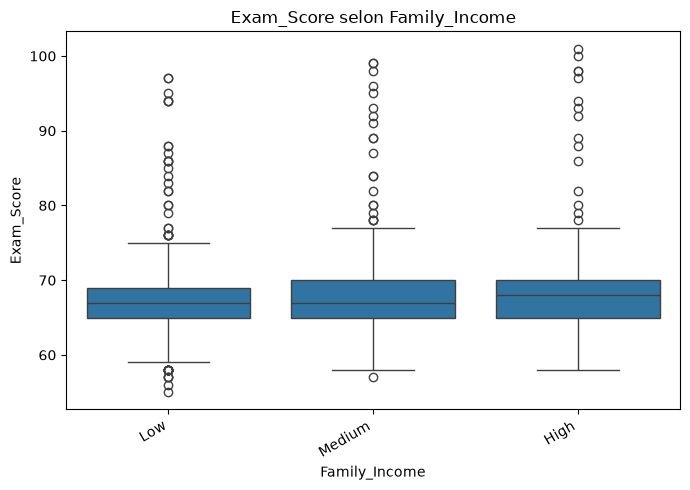

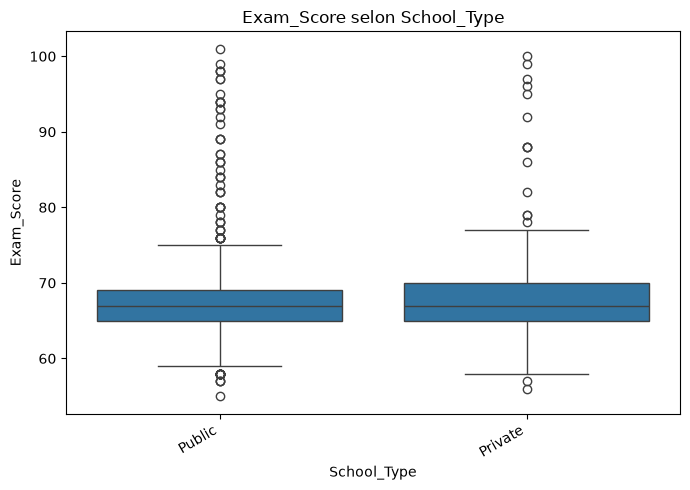

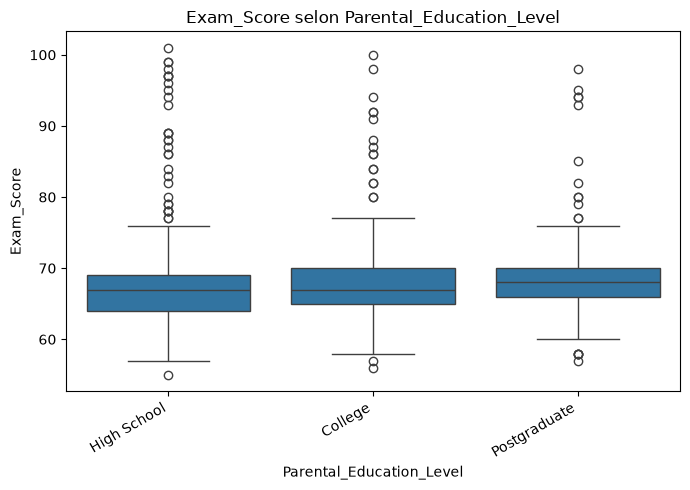

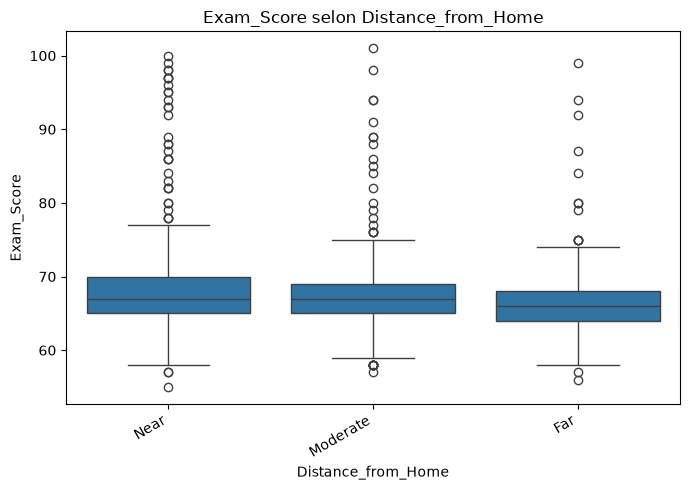

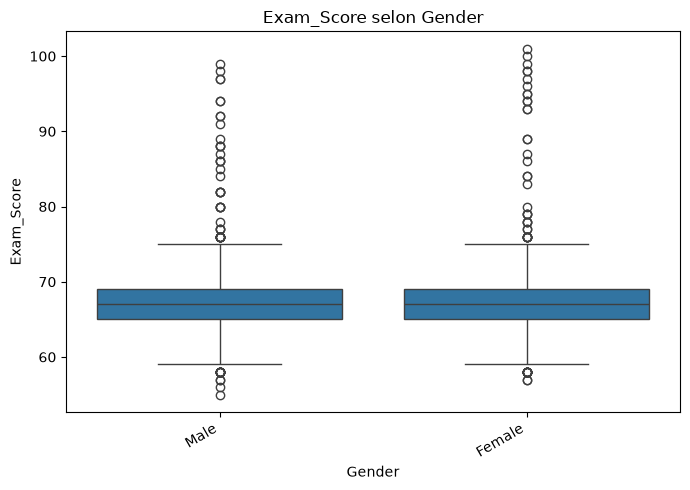

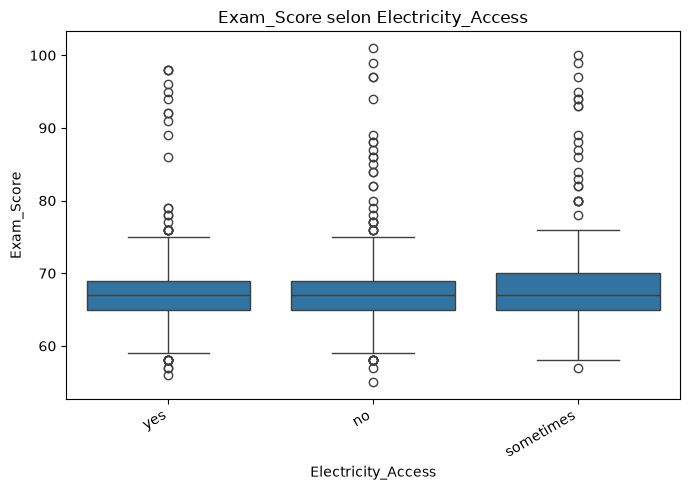

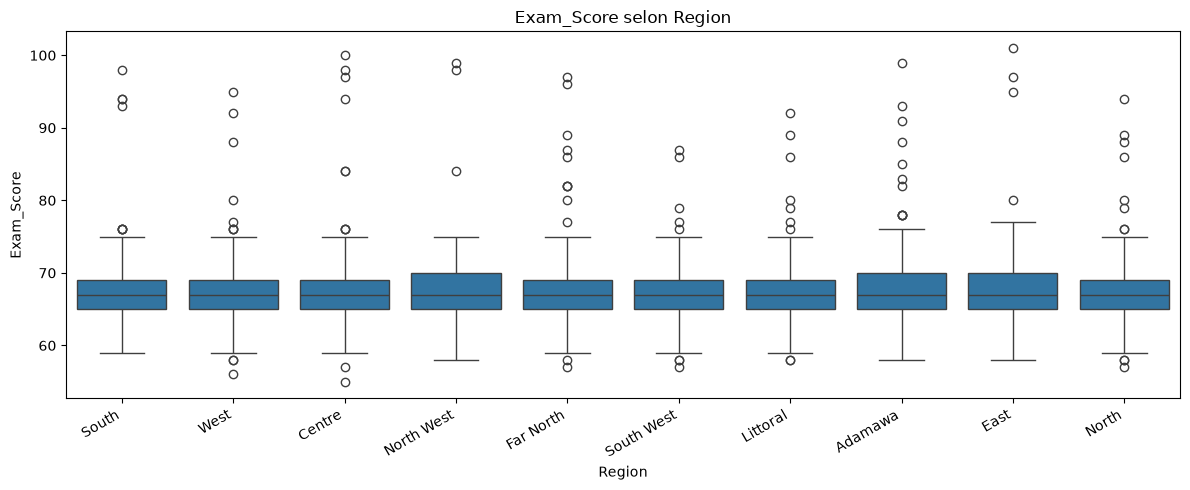

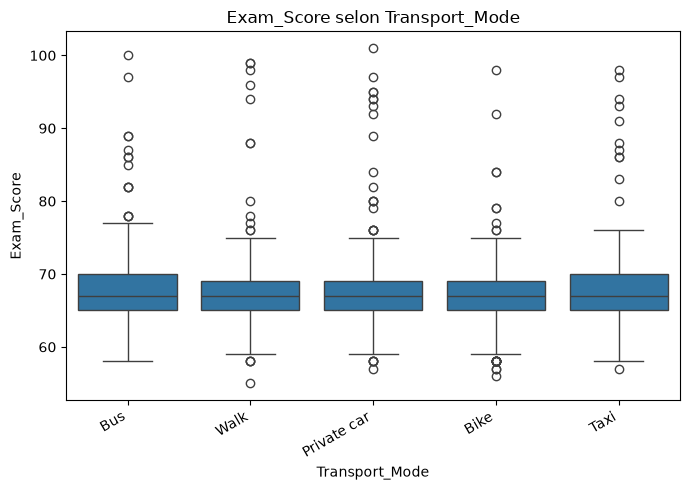

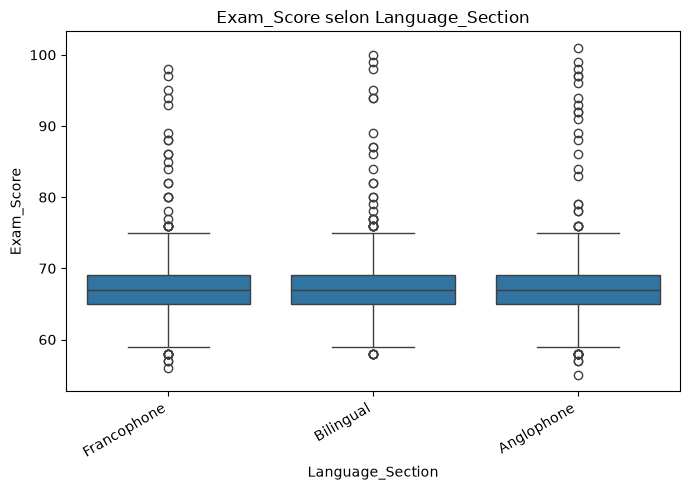

,variable,F_statistic,p_value
0,Parental_Involvement,84.487655,5.875479e-37
1,Access_to_Resources,98.004409,1.139299e-42
2,Extracurricular_Activities,27.491709,1.626678e-07
3,Internet_Access,17.547612,2.838505e-05
4,Family_Income,29.793861,1.314369e-13
5,School_Type,0.516607,4.723181e-01
6,Parental_Education_Level,24.444312,1.004100e-15
7,Distance_from_Home,19.265178,1.962621e-12
8,Gender,0.027281,8.688153e-01
9,Electricity_Access,0.298376,7.420320e-01


In [75]:
# Analyse ajoutée : variables catégorielles de faible cardinalité, boxplots et ANOVA
low_cardinality_categoricals = [
    col for col in categorical_columns_eda
    if SPP[col].nunique(dropna=False) <= 10
]
print("Variables catégorielles de faible cardinalité :", low_cardinality_categoricals)
for col in low_cardinality_categoricals:
    plt.figure(figsize=(max(7, 1.2 * SPP[col].nunique(dropna=False)), 5))
    sns.boxplot(data=SPP, x=col, y=TARGET)
    plt.title(f"{TARGET} selon {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

try:
    from scipy.stats import f_oneway
    anova_rows = []
    for col in low_cardinality_categoricals:
        groups = [g[TARGET].dropna().values for _, g in SPP.groupby(col, dropna=False)]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) >= 2:
            stat, pvalue = f_oneway(*groups)
            anova_rows.append({"variable": col, "F_statistic": stat, "p_value": pvalue})
    anova_results = pd.DataFrame(anova_rows)
    display(anova_results)
except ImportError:
    print("ANOVA non exécutée : scipy n’est pas installé.")


In [76]:
# 12. Cohérence logique métier
# Règle métier FIXE (indépendante des données) -> pas de fuite
SPP["Exam_Score"] = SPP["Exam_Score"].clip(upper=100)

# Vérifications de validité (aucune ligne invalide attendue)
assert (SPP["Attendance"].between(0, 100)).all()
assert (SPP["Hours_Studied"] >= 0).all()
assert (SPP["Sleep_Hours"].between(3, 12)).all()   # borne réaliste, pas physique
assert (SPP["Tutoring_Sessions"] >= 0).all()
assert (SPP["Physical_Activity"] >= 0).all()
assert (SPP["Previous_Scores"].between(0, 100)).all()
assert (SPP["Class_Size"] > 0).all()

# Les outliers IQR détectés sont conservés (aucun winsorizing) :
# - Hours_Studied : 43 outliers (queues 1-3h et 37-44h), valeurs plausibles
# - Tutoring_Sessions : 430 outliers (~6.5%), distribution de comptage
#   naturelle (Poisson-like), pas du bruit
# - Exam_Score : 104 outliers, cohérent avec le clip métier ci-dessus

In [77]:
print(f"Tutoring_Sessions outliers : {430} soit {430/6607:.2%} du dataset")

Tutoring_Sessions outliers : 430 soit 6.51% du dataset


In [78]:
# Les outliers IQR détectés sont conservés (aucun winsorizing) :
# - Hours_Studied : 43 outliers (queues 1-3h et 37-44h), valeurs plausibles
# - Tutoring_Sessions : 430 outliers (6.51%), valeurs 4 à 8 sessions,
#   distribution de comptage décroissante (Poisson-like), pas du bruit
# - Exam_Score : 104 outliers, cohérent avec le clip métier ci-dessus
#   (Q3=69, limite haute=75, donc les valeurs 76-100 sont "hautes" mais
#   plausibles pour de bons élèves)

Variables numériques importantes : ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Sleep_Hours']


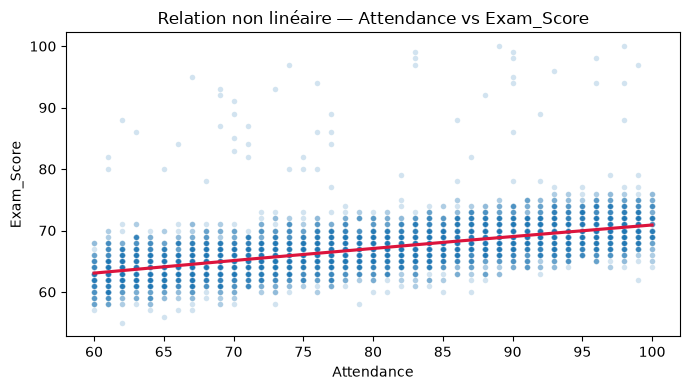

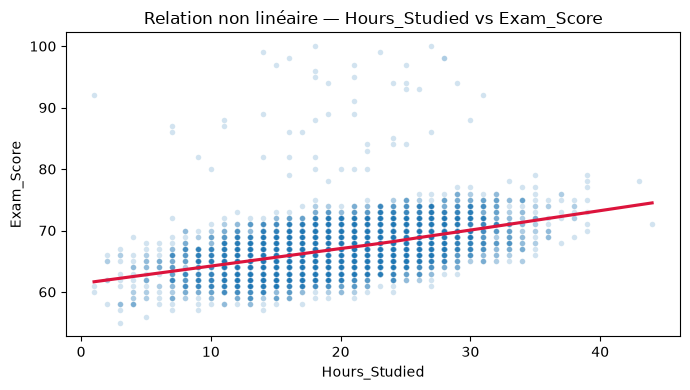

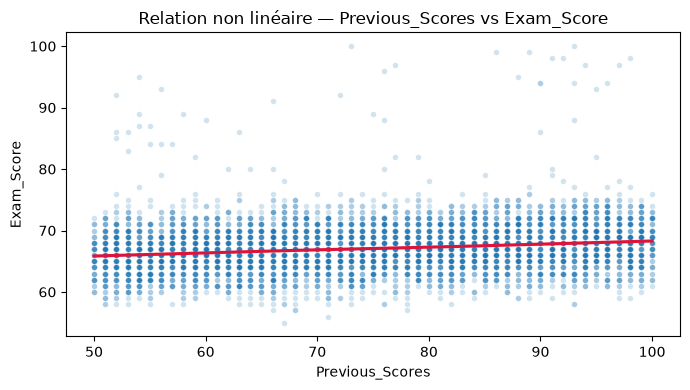

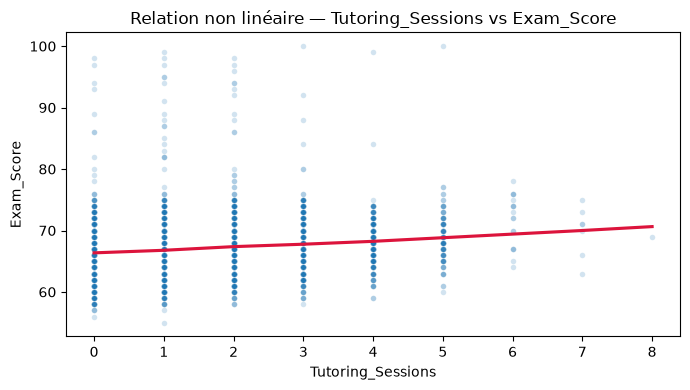

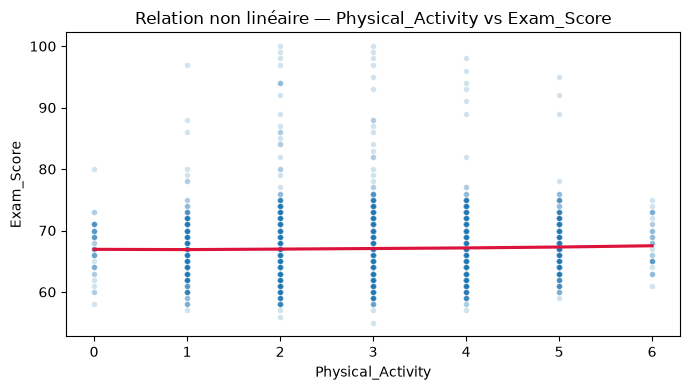

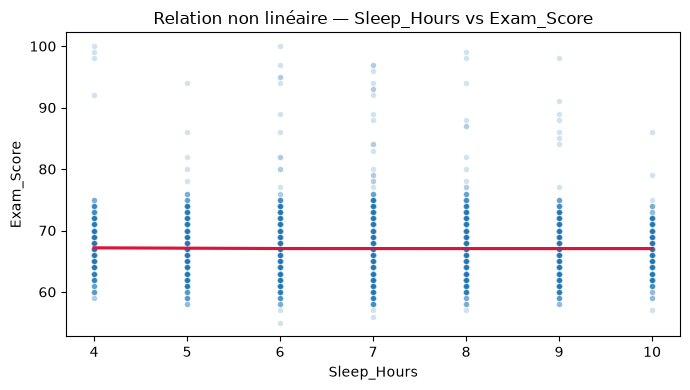

In [79]:
# Exploration ajoutée : relations non linéaires des variables numériques importantes
# Les variables importantes sont choisies par corrélation absolue avec la cible.
_num_for_rank = [c for c in numeric_columns_eda if c != TARGET]
_corr_rank = SPP[_num_for_rank + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)
important_numeric = _corr_rank.head(min(6, len(_corr_rank))).index.tolist()
print("Variables numériques importantes :", important_numeric)
for col in important_numeric:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.scatterplot(data=SPP, x=col, y=TARGET, alpha=0.20, s=16, ax=ax)
    sns.regplot(data=SPP, x=col, y=TARGET, scatter=False, lowess=True,
                color="crimson", ax=ax)
    ax.set_title(f"Relation non linéaire — {col} vs {TARGET}")
    plt.tight_layout()
    plt.show()


In [80]:
# PREPROCESSING

In [81]:
# 1. Separer X de y
X = SPP.drop(columns=["Exam_Score"])
y = SPP["Exam_Score"]

In [82]:
# 2. Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

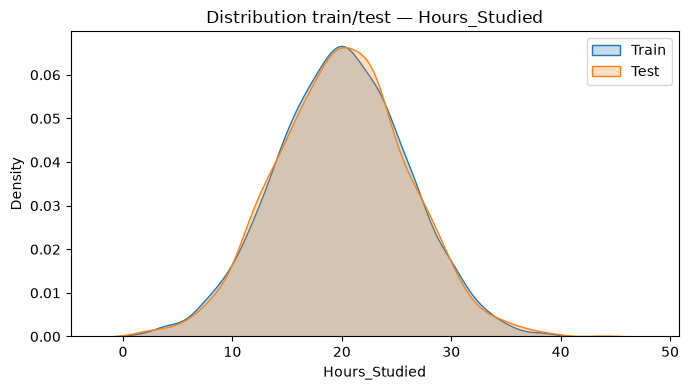

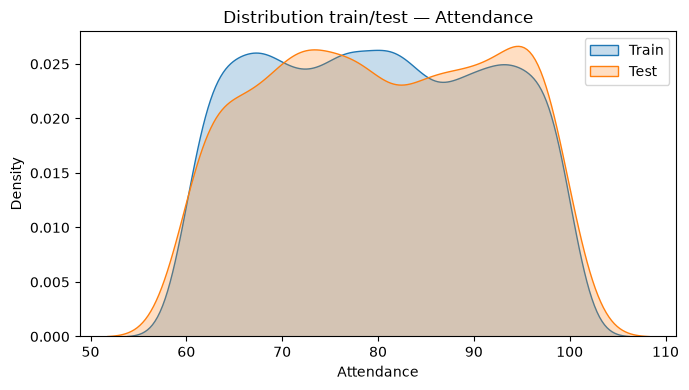

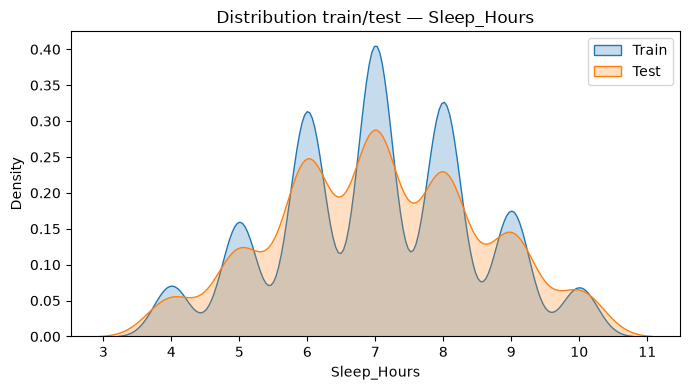

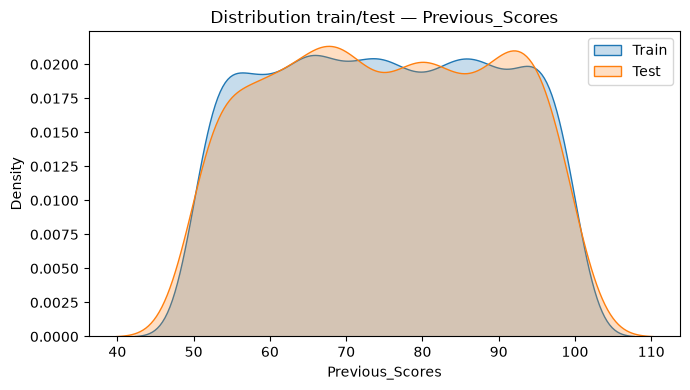

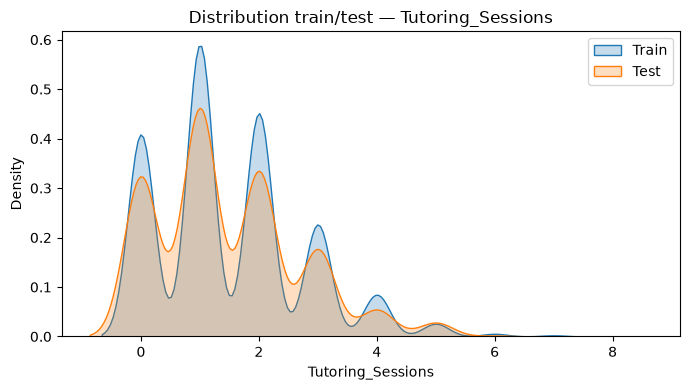

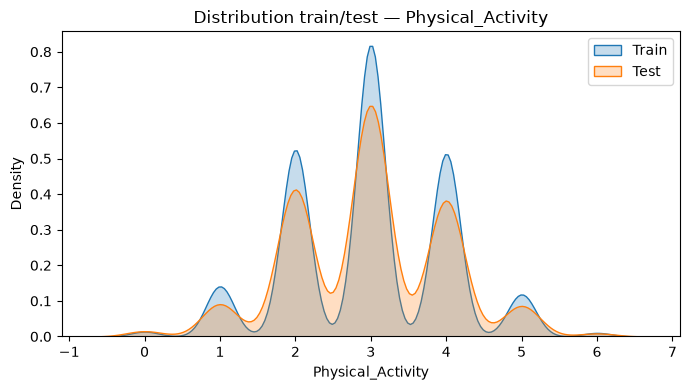

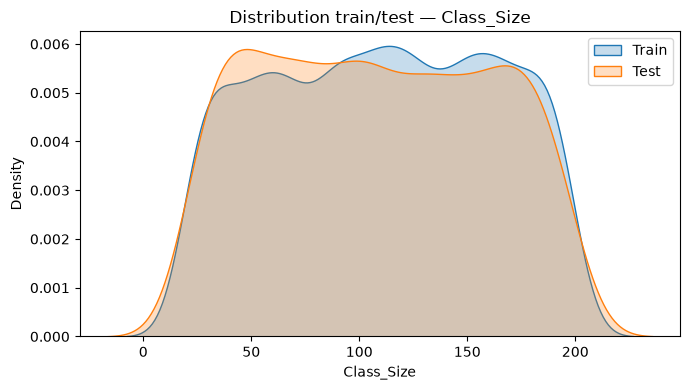

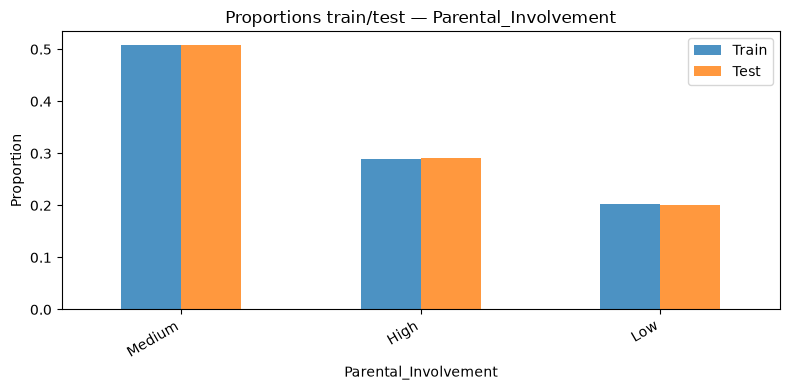

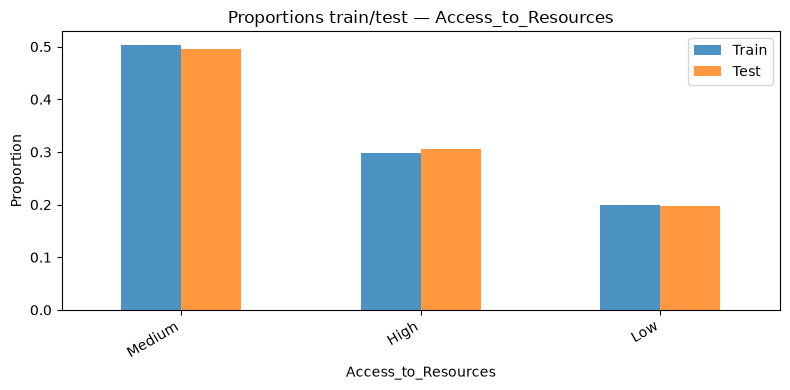

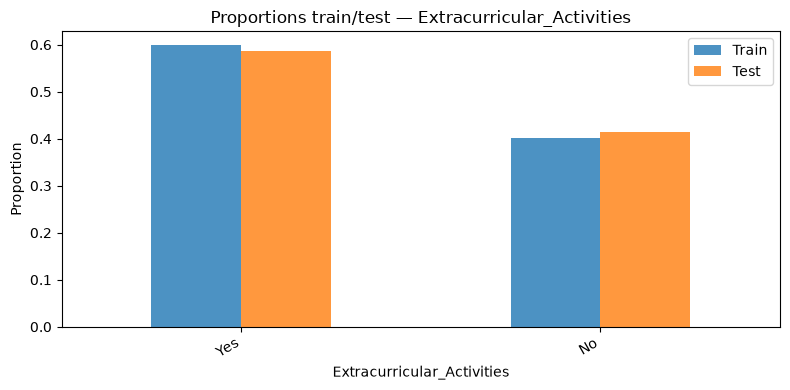

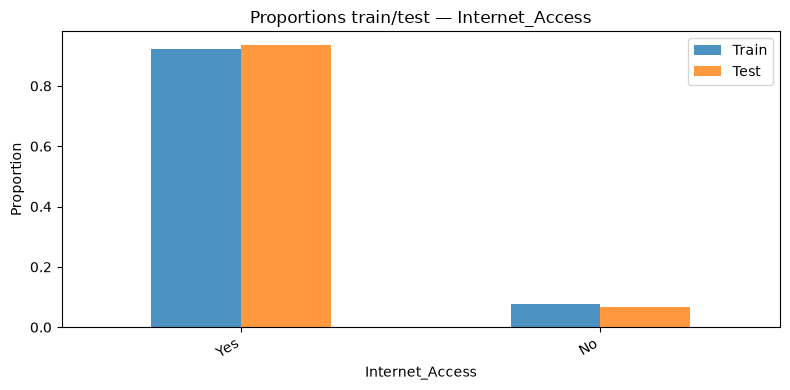

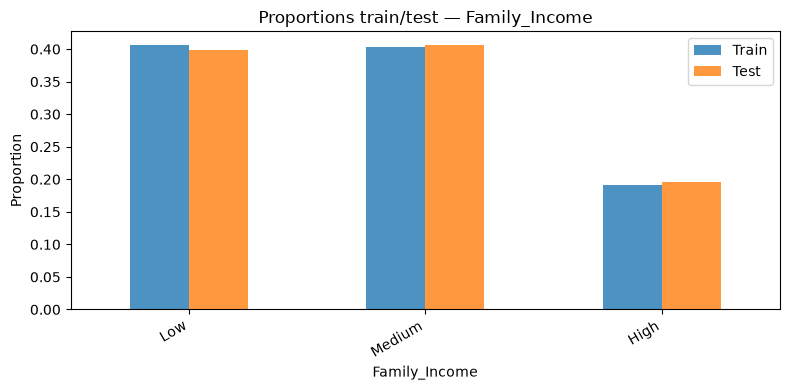

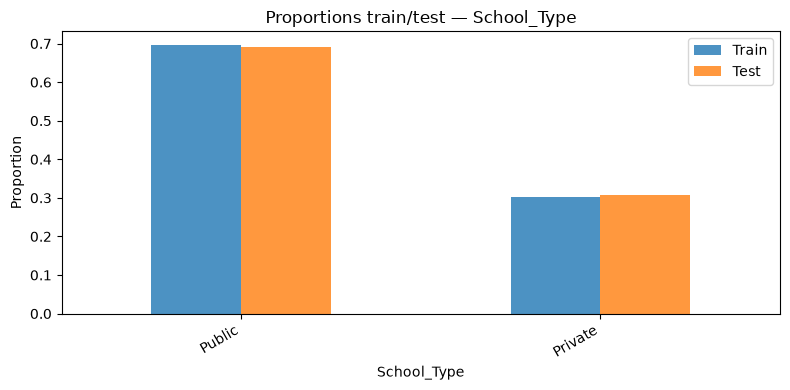

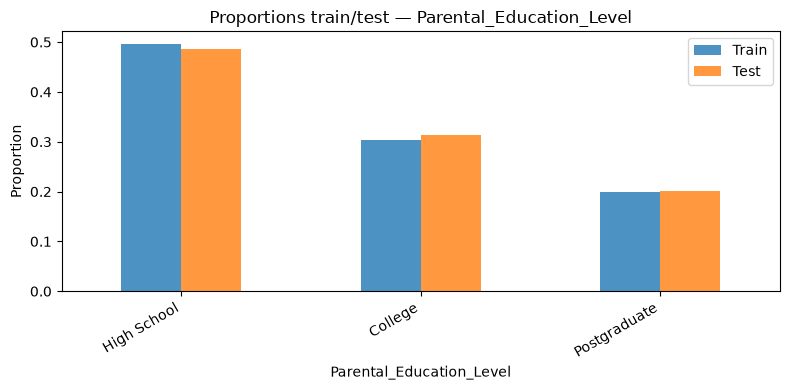

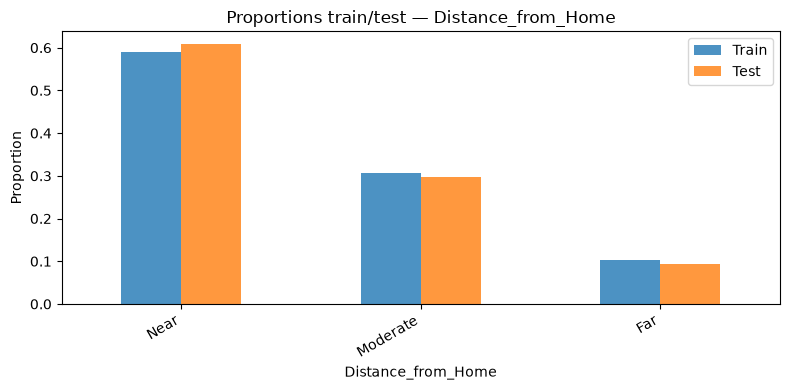

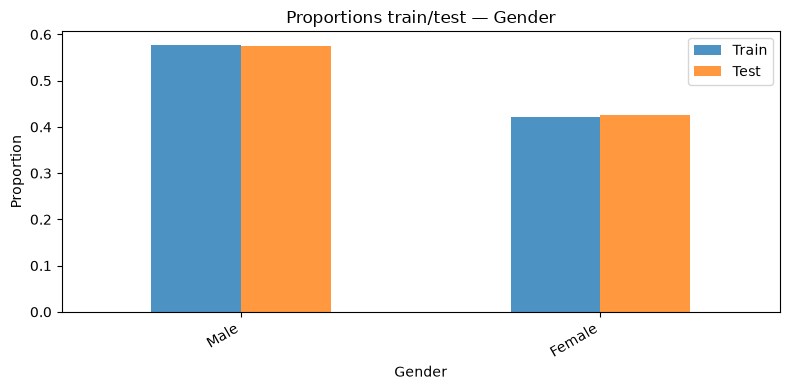

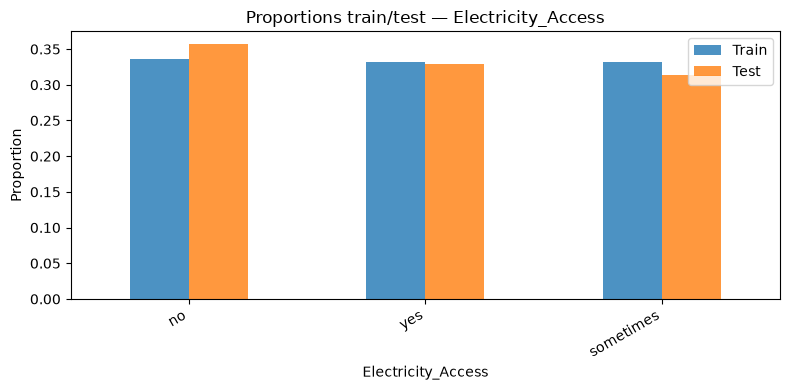

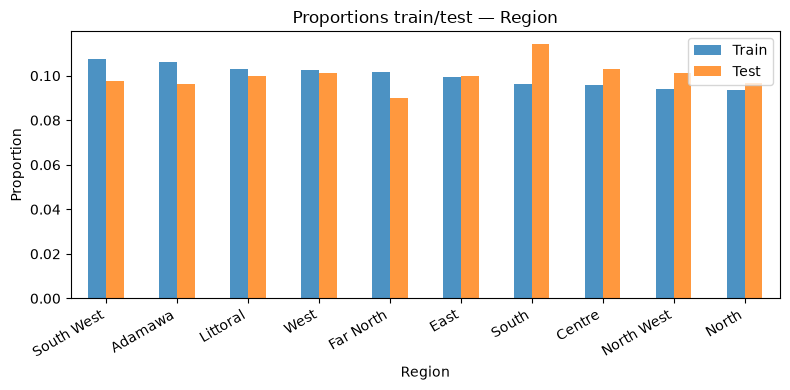

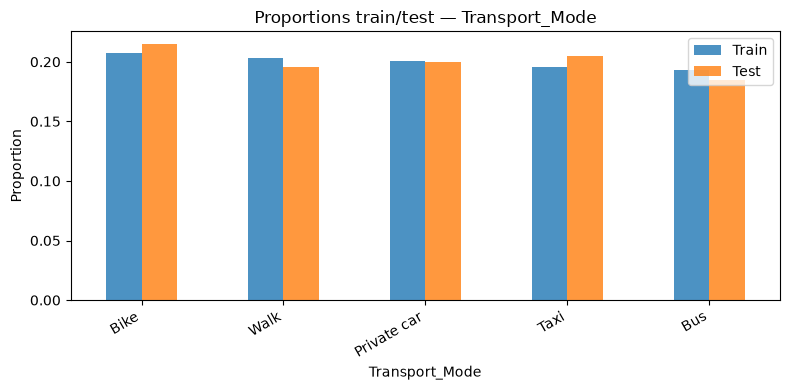

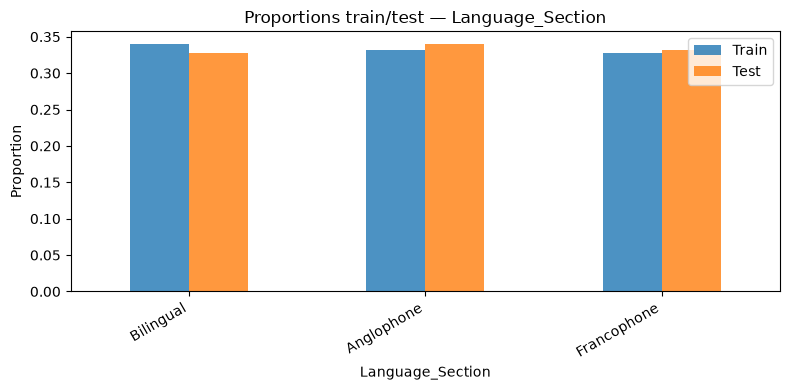

In [83]:
# Comparaison ajoutée : distributions train/test sans modifier les jeux de données
for col in numeric_features:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.kdeplot(X_train[col].dropna(), label="Train", fill=True, alpha=.25, ax=ax)
    sns.kdeplot(X_test[col].dropna(), label="Test", fill=True, alpha=.25, ax=ax)
    ax.set_title(f"Distribution train/test — {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()
for col in categorical_features:
    dist = pd.concat([
        X_train[col].value_counts(normalize=True).rename("Train"),
        X_test[col].value_counts(normalize=True).rename("Test")
    ], axis=1).fillna(0)
    dist.plot(kind="bar", figsize=(8, 4), alpha=.8)
    plt.title(f"Proportions train/test — {col}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [84]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 3. pipelines numerique et categorielle
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [85]:
# 4. ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [86]:
# Application et sauvegarde ajoutées : le preprocessor est ajusté uniquement sur le train
import joblib
preprocessor_fitted = preprocessor.fit(X_train, y_train)
X_train_preprocessed = preprocessor_fitted.transform(X_train)
X_test_preprocessed = preprocessor_fitted.transform(X_test)
preprocessor_path = "preprocessor.joblib"
joblib.dump(preprocessor_fitted, preprocessor_path)
print("Preprocessor sauvegardé dans :", preprocessor_path)
print("Shapes transformées — train:", X_train_preprocessed.shape, "test:", X_test_preprocessed.shape)


Preprocessor sauvegardé dans : preprocessor.joblib
Shapes transformées — train: (5285, 53) test: (1322, 53)


In [87]:
# Rapport optionnel ajouté : ydata-profiling
# Le rapport est généré seulement si le paquet est disponible.
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(SPP, title="Audit SPP", explorative=True, minimal=True)
    profile.to_file("ydata_profile.html")
    print("Rapport généré : ydata_profile.html")
except ImportError:
    print("Rapport ydata-profiling non généré : paquet non installé.")
except Exception as exc:
    print(f"Rapport ydata-profiling non généré : {exc}")


Rapport ydata-profiling non généré : paquet non installé.


## Compléments EDA et traçabilité des transformations

Cette section est volontairement ajoutée en fin de notebook afin de ne modifier aucune cellule existante. Les graphiques sont enregistrés dans `figures/` (créé automatiquement si nécessaire). Les vérifications sont conditionnelles : une analyse est ignorée avec un message explicite si la variable, la colonne cible ou une dépendance optionnelle n'est pas disponible.

Décisions EDA :
- comparer `y_train` et `y_test` par histogrammes/KDE pour vérifier un éventuel décalage de la cible après le découpage ;
- sélectionner au plus cinq variables numériques selon la corrélation absolue avec `Exam_Score`, puis utiliser un `pairplot` avec la cible ;
- examiner les variables catégorielles de cardinalité strictement supérieure à 5 par boxplots ; l'ANOVA à un facteur n'est calculée que si la cible est numérique et qu'au moins deux groupes ont suffisamment d'observations ;
- ne pas supprimer ni winsoriser les observations dans cette étape descriptive ; les catégories rares peuvent être limitées aux modalités les plus fréquentes uniquement pour conserver des figures lisibles ;
- afficher les noms de colonnes produits par le préprocesseur afin de contrôler l'encodage et l'ordre des variables avant modélisation.

In [88]:
# EDA complémentaire robuste : cellules existantes inchangées
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def _save_close(fig, filename):
    """Sauvegarde une figure sans interrompre le notebook en cas de problème."""
    path = FIGURES_DIR / filename
    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Figure sauvegardée : {path}")
    except Exception as exc:
        print(f"Figure non sauvegardée ({filename}) : {exc}")
    finally:
        try:
            plt.close(fig)
        except Exception:
            pass

# 1) Vérification graphique de la distribution de y_train / y_test.
if "y_train" in globals() and "y_test" in globals():
    try:
        ytr = pd.Series(y_train).dropna()
        yte = pd.Series(y_test).dropna()
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.histplot(ytr, stat="density", kde=True, color="tab:blue", alpha=.30, label="Train", ax=ax)
        sns.histplot(yte, stat="density", kde=True, color="tab:orange", alpha=.30, label="Test", ax=ax)
        ax.set(title="Distribution de la cible : y_train vs y_test", xlabel=str(globals().get("TARGET", "cible")), ylabel="Densité")
        ax.legend()
        _save_close(fig, "distribution_y_train_y_test.png")
        print("Tailles y_train / y_test :", len(ytr), "/", len(yte))
    except Exception as exc:
        print("Vérification y_train/y_test ignorée :", exc)
else:
    print("Vérification y_train/y_test ignorée : y_train ou y_test absent.")

# 2) Pairplot des cinq variables numériques les plus corrélées à Exam_Score.
_df_eda = globals().get("SPP")
_target_eda = globals().get("TARGET", "Exam_Score")
if isinstance(_df_eda, pd.DataFrame) and _target_eda in _df_eda.columns:
    _num_eda = _df_eda.select_dtypes(include=np.number).columns.tolist()
    _num_predictors = [c for c in _num_eda if c != _target_eda]
    try:
        _corr = _df_eda[_num_predictors + [_target_eda]].corr(numeric_only=True)[_target_eda].drop(_target_eda).abs().sort_values(ascending=False)
        _top5 = _corr.head(5).index.tolist()
        print("Variables retenues pour le pairplot :", _top5)
        if _top5:
            _pair_data = _df_eda[_top5 + [_target_eda]].dropna()
            if len(_pair_data) >= 2:
                _pair = sns.pairplot(_pair_data, vars=_top5 + [_target_eda], corner=True, diag_kind="hist", plot_kws={"alpha": .35, "s": 16})
                _pair.fig.suptitle("Pairplot — cinq variables numériques les plus corrélées à Exam_Score", y=1.02)
                _save_close(_pair.fig, "pairplot_top5_correlations.png")
            else:
                print("Pairplot ignoré : moins de deux lignes complètes.")
        else:
            print("Pairplot ignoré : aucune variable numérique explicative disponible.")
    except Exception as exc:
        print("Pairplot ignoré :", exc)
else:
    print("Pairplot ignoré : SPP ou la cible est absent(e).")

# 3) Variables catégorielles de cardinalité > 5 : boxplots et ANOVA si applicable.
if isinstance(_df_eda, pd.DataFrame) and _target_eda in _df_eda.columns:
    _cat_eda = _df_eda.select_dtypes(exclude=np.number).columns.tolist()
    _high_card = [c for c in _cat_eda if _df_eda[c].nunique(dropna=True) > 5]
    print("Variables catégorielles de cardinalité > 5 :", _high_card)
    _anova_rows = []
    for _col in _high_card:
        try:
            _plot_df = _df_eda[[_col, _target_eda]].dropna().copy()
            # Pour la lisibilité, afficher les 30 modalités les plus fréquentes.
            _order = _plot_df[_col].value_counts().head(30).index.tolist()
            _plot_df = _plot_df[_plot_df[_col].isin(_order)]
            if _plot_df.empty:
                print(f"Boxplot ignoré pour {_col} : aucune donnée exploitable.")
                continue
            _fig, _ax = plt.subplots(figsize=(max(8, min(18, 0.45 * len(_order) + 4)), 5))
            sns.boxplot(data=_plot_df, x=_col, y=_target_eda, order=_order, ax=_ax)
            _ax.set_title(f"{_target_eda} selon {_col} (cardinalité > 5)")
            _ax.tick_params(axis="x", rotation=45)
            _fig.tight_layout()
            _safe_name = "".join(ch if ch.isalnum() or ch in "_-" else "_" for ch in str(_col))
            _save_close(_fig, f"boxplot_high_cardinality_{_safe_name}.png")

            if pd.api.types.is_numeric_dtype(_plot_df[_target_eda]):
                _groups = [_g[_target_eda].to_numpy() for _, _g in _plot_df.groupby(_col, observed=True)]
                _groups = [_g[~pd.isna(_g)] for _g in _groups if len(_g) >= 2]
                if len(_groups) >= 2:
                    try:
                        from scipy.stats import f_oneway
                        _f, _p = f_oneway(*_groups)
                        _anova_rows.append({"variable": _col, "F_statistic": float(_f), "p_value": float(_p), "n_groups": len(_groups)})
                    except ImportError:
                        print("ANOVA ignorée : scipy n'est pas disponible.")
                else:
                    print(f"ANOVA non applicable pour {_col} : moins de deux groupes avec au moins deux observations.")
            else:
                print(f"ANOVA non applicable pour {_col} : cible non numérique.")
        except Exception as exc:
            print(f"Analyse ignorée pour {_col} : {exc}")
    anova_results_high_cardinality = pd.DataFrame(_anova_rows)
    print("Résultats ANOVA (variables de cardinalité > 5) :")
    print(anova_results_high_cardinality if not anova_results_high_cardinality.empty else "Aucun résultat calculable.")
else:
    print("Analyse catégorielle ignorée : SPP ou la cible est absent(e).")

# 4) Contrôle des noms de colonnes après transformation du préprocesseur.
if "preprocessor_fitted" in globals():
    try:
        transformed_feature_names = list(preprocessor_fitted.get_feature_names_out())
        print(f"Nombre de colonnes après transformation : {len(transformed_feature_names)}")
        print("Noms de colonnes transformées :")
        print(transformed_feature_names)
        if "X_train_preprocessed" in globals():
            print("Vérification train :", X_train_preprocessed.shape[1] == len(transformed_feature_names), X_train_preprocessed.shape)
        if "X_test_preprocessed" in globals():
            print("Vérification test :", X_test_preprocessed.shape[1] == len(transformed_feature_names), X_test_preprocessed.shape)
    except Exception as exc:
        print("Noms de colonnes transformées indisponibles :", exc)
else:
    print("Contrôle des colonnes transformées ignoré : preprocessor_fitted absent.")


Figure sauvegardée : figures/distribution_y_train_y_test.png
Tailles y_train / y_test : 5285 / 1322
Variables retenues pour le pairplot : ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Figure sauvegardée : figures/pairplot_top5_correlations.png
Variables catégorielles de cardinalité > 5 : ['Region']
Figure sauvegardée : figures/boxplot_high_cardinality_Region.png
Résultats ANOVA (variables de cardinalité > 5) :
  variable  F_statistic   p_value  n_groups
0   Region     0.392534  0.939343        10
Nombre de colonnes après transformation : 53
Noms de colonnes transformées :
['numeric__Hours_Studied', 'numeric__Attendance', 'numeric__Sleep_Hours', 'numeric__Previous_Scores', 'numeric__Tutoring_Sessions', 'numeric__Physical_Activity', 'numeric__Class_Size', 'categorical__Parental_Involvement_High', 'categorical__Parental_Involvement_Low', 'categorical__Parental_Involvement_Medium', 'categorical__Access_to_Resources_High', 'categorical__Access_

In [89]:
# Feature selection 1/3 — agrégation des importances par variable d'origine
# Les importances des modalités one-hot sont regroupées au niveau de la variable source.
from collections import defaultdict
from sklearn.ensemble import ExtraTreesRegressor

if "X_train_preprocessed" not in globals() or "y_train" not in globals():
    raise RuntimeError("X_train_preprocessed et y_train doivent être disponibles avant cette cellule.")

_feature_names_transformed = list(
    preprocessor_fitted.get_feature_names_out()
    if "preprocessor_fitted" in globals()
    else preprocessor.get_feature_names_out()
)
_selector_model = ExtraTreesRegressor(
    n_estimators=250,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)
_selector_model.fit(X_train_preprocessed, y_train)

# get_feature_names_out() produit notamment numeric__Age et categorical__Gender_Female.
def _source_feature_name(name):
    name = str(name)
    return name.split("__", 1)[1] if "__" in name else name

_aggregated = defaultdict(float)
for _name, _importance in zip(_feature_names_transformed, _selector_model.feature_importances_):
    _aggregated[_source_feature_name(_name)] += float(_importance)

aggregated_importances = (
    pd.Series(_aggregated, name="importance")
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index()
)
print("Importances agrégées par variable d'origine :")
print(aggregated_importances.to_string(index=False))


Importances agrégées par variable d'origine :
                              feature  importance
                           Attendance    0.386407
                        Hours_Studied    0.222905
                      Previous_Scores    0.038162
             Access_to_Resources_High    0.024699
            Parental_Involvement_High    0.023238
                    Tutoring_Sessions    0.022249
             Parental_Involvement_Low    0.013602
              Access_to_Resources_Low    0.011755
                   Family_Income_High    0.011435
                          Sleep_Hours    0.010558
                    Family_Income_Low    0.010288
Parental_Education_Level_Postgraduate    0.009878
 Parental_Education_Level_High School    0.009667
                    Physical_Activity    0.009640
              Distance_from_Home_Near    0.009314
           Transport_Mode_Private car    0.009163
         Electricity_Access_sometimes    0.008581
                           Class_Size    0.007964
    

In [90]:
# Feature selection 2/3 — permutation importance avec CV
# IMPORTANT :
# La sélection des features est maintenant réalisée UNIQUEMENT sur le train set.
# Le test set reste totalement isolé jusqu'à l'évaluation finale.

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.inspection import permutation_importance

# Vérification que le train/test split existe
if "X_train" not in globals() or "y_train" not in globals():
    raise RuntimeError(
        "X_train et y_train doivent être disponibles avant cette cellule."
    )

# Pour une cible de régression :
# création de strates à partir des quantiles de y_train

_y_bins_train = pd.qcut(
    pd.Series(y_train).reset_index(drop=True),
    q=min(10, pd.Series(y_train).nunique()),
    labels=False,
    duplicates="drop"
)

if _y_bins_train.nunique() < 2:
    raise RuntimeError(
        "Impossible de construire au moins deux strates pour y_train."
    )

# Cross-validation uniquement sur le train set

_stratified_cv_train = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Pipeline complet pour la sélection des features
# Le preprocessing sera réentraîné à l'intérieur de chaque fold

_permutation_pipeline = Pipeline([
    ("preprocessor", preprocessor_fitted),
    ("model", ExtraTreesRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        min_samples_leaf=5,
    )),
])

# Cross-validation UNIQUEMENT sur X_train / y_train

_X_train_cv = X_train.reset_index(drop=True)
_y_train_cv = pd.Series(y_train).reset_index(drop=True)

_cv_results = cross_validate(
    _permutation_pipeline,
    _X_train_cv,
    _y_train_cv,
    cv=_stratified_cv_train.split(
        _X_train_cv,
        _y_bins_train
    ),
    scoring="r2",
    return_estimator=True,
    n_jobs=1,
    error_score="raise"
)

cv_r2_scores = np.asarray(
    _cv_results["test_score"],
    dtype=float
)

print(
    f"R² CV moyen sur TRAIN : "
    f"{cv_r2_scores.mean():.4f} ± "
    f"{cv_r2_scores.std():.4f}"
)


# ---------------------------------------------------------
# Permutation importance sur les folds de validation
# ---------------------------------------------------------

_cv_importances = []

for _estimator, (_, _valid_idx) in zip(
    _cv_results["estimator"],
    _stratified_cv_train.split(
        _X_train_cv,
        _y_bins_train
    ),
):

    _perm = permutation_importance(
        _estimator,
        _X_train_cv.iloc[_valid_idx],
        _y_train_cv.iloc[_valid_idx],
        scoring="r2",
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    _cv_importances.append(
        _perm.importances_mean
    )


_cv_importances = np.asarray(
    _cv_importances
)

permutation_importances_cv = pd.DataFrame({
    "feature": _X_train_cv.columns,
    "importance_mean": _cv_importances.mean(axis=0),
    "importance_std_across_folds": _cv_importances.std(axis=0),
}).sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)


print(
    "Importances par permutation "
    "(CV réalisée uniquement sur TRAIN) :"
)

print(
    permutation_importances_cv.to_string(index=False)
)

R² CV moyen sur TRAIN : 0.6214 ± 0.0633


/home/nick/Bureau/app/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nick/Bureau/app/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nick/Bureau/app/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nick/Bureau/app/venv/lib/python3.14/site-packages/sklea

Importances par permutation (CV réalisée uniquement sur TRAIN) :
                   feature  importance_mean  importance_std_across_folds
                Attendance         0.674516                     0.078142
             Hours_Studied         0.357045                     0.046669
       Access_to_Resources         0.047767                     0.006521
      Parental_Involvement         0.043090                     0.008000
           Previous_Scores         0.030543                     0.003786
         Tutoring_Sessions         0.009959                     0.001843
  Parental_Education_Level         0.007013                     0.001515
             Family_Income         0.006215                     0.003086
        Distance_from_Home         0.004423                     0.001298
Extracurricular_Activities         0.002303                     0.000541
        Electricity_Access         0.001573                     0.000961
               School_Type         0.001112                

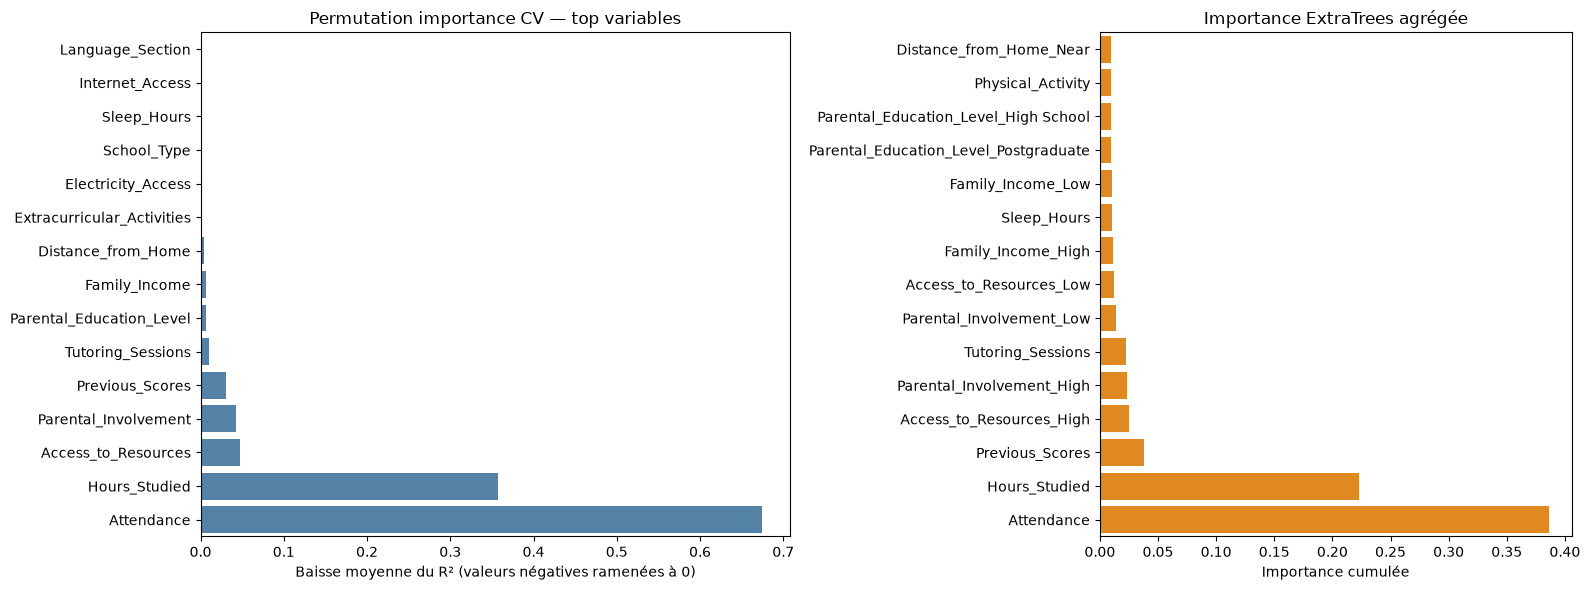

Variables proposées pour la sélection (16) : ['Attendance', 'Hours_Studied', 'Access_to_Resources', 'Parental_Involvement', 'Previous_Scores', 'Tutoring_Sessions', 'Parental_Education_Level', 'Family_Income', 'Distance_from_Home', 'Extracurricular_Activities', 'Electricity_Access', 'School_Type', 'Sleep_Hours', 'Internet_Access', 'Language_Section', 'Physical_Activity']


In [91]:
# Feature selection 3/3 — visualisation finale et proposition de sélection
# Les variables sont classées selon la permutation importance CV; les importances négatives
# sont conservées dans le tableau mais ramenées à zéro pour la sélection et l'affichage.
if "permutation_importances_cv" not in globals():
    raise RuntimeError("Exécutez d'abord la cellule de permutation importance avec CV.")

_final_importances = permutation_importances_cv.copy()
_final_importances["importance_for_selection"] = _final_importances["importance_mean"].clip(lower=0)
_selected_features = _final_importances.loc[
    _final_importances["importance_for_selection"] > 0, "feature"
].tolist()
if not _selected_features:
    _selected_features = _final_importances.head(min(5, len(_final_importances)))["feature"].tolist()
selected_features = _selected_features

_top_n = min(15, len(_final_importances))
_plot_data = _final_importances.head(_top_n).sort_values("importance_for_selection")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.25, 1]})
sns.barplot(
    data=_plot_data, x="importance_for_selection", y="feature",
    color="steelblue", ax=axes[0]
)
axes[0].set_title("Permutation importance CV — top variables")
axes[0].set_xlabel("Baisse moyenne du R² (valeurs négatives ramenées à 0)")
axes[0].set_ylabel("")

_agg_plot = aggregated_importances.head(_top_n).sort_values("importance") if "aggregated_importances" in globals() else pd.DataFrame()
if not _agg_plot.empty:
    sns.barplot(data=_agg_plot, x="importance", y="feature", color="darkorange", ax=axes[1])
    axes[1].set_title("Importance ExtraTrees agrégée")
    axes[1].set_xlabel("Importance cumulée")
    axes[1].set_ylabel("")
else:
    axes[1].text(.5, .5, "Importances agrégées indisponibles", ha="center", va="center")
    axes[1].set_axis_off()
plt.tight_layout()
plt.show()
print(f"Variables proposées pour la sélection ({len(selected_features)}) : {selected_features}")


In [92]:
# Résultat final de la sélection des features :
# les 6 variables retenues après analyse de la permutation importance CV.

final_features = [
    'Attendance',
    'Hours_Studied',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Access_to_Resources',
    'Parental_Involvement'
]

final_features_list = pd.DataFrame({"feature": final_features})
final_features_list.to_csv("final_features_list.csv", index=False)

print(f"Liste finale des features ({len(final_features)}) : {final_features}")
print("Liste sauvegardée dans final_features_list.csv")

Liste finale des features (6) : ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources', 'Parental_Involvement']
Liste sauvegardée dans final_features_list.csv


In [93]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
import pandas as pd

# 1. Sélectionner les 6 features finales

final_features = [
    "Attendance",
    "Hours_Studied",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Access_to_Resources",
    "Parental_Involvement"
]

X_train_final = X_train[final_features]

# Vérification de l'ordre des colonnes
print("Ordre des features :", X_train_final.columns.tolist())


# 2. Définir les types de features

numeric_features = [
    "Attendance",
    "Hours_Studied",
    "Previous_Scores",
    "Tutoring_Sessions"
]

ordinal_features = [
    "Access_to_Resources",
    "Parental_Involvement"
]


# 3. Définir l'OrdinalEncoder commun

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["Low", "Medium", "High"],
        ["Low", "Medium", "High"]
    ],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


# 4. Définir le preprocessing pour Ridge
# Les variables numériques sont standardisées
# Les variables ordinales sont encodées

preprocessor_ridge = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("ord", ordinal_encoder, ordinal_features)
])


# 5. Définir le preprocessing pour les modèles à base d'arbres
# Pas besoin de StandardScaler pour Random Forest et Gradient Boosting

preprocessor_trees = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("ord", ordinal_encoder, ordinal_features)
])


# 6. Créer les trois pipelines

models = {
    "Ridge": Pipeline([
        ("preprocessor", preprocessor_ridge),
        ("model", Ridge(alpha=1.0))          # à ajuster selon mon tuning
    ]),

    "RandomForest": Pipeline([
        ("preprocessor", preprocessor_trees),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,                  # à justifier selon mon raisonnement
            random_state=42
        ))
    ]),

    "GradientBoosting": Pipeline([
        ("preprocessor", preprocessor_trees),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,               # à ajuster selon mon tuning
            random_state=42
        ))
    ])
}


# 7. Créer les bins sur la target pour stratifier

# pd.qcut découpe Exam_Score en groupes de taille égale

y_bins = pd.qcut(y_train, q=5, labels=False)

# Définir le même split pour tous les modèles

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Transformer le générateur de folds en liste
# afin de pouvoir réutiliser exactement les mêmes folds
# pour tous les modèles

folds = list(skf.split(X_train_final, y_bins))


# 8. Définir les métriques qu'on veut calculer à chaque fold

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}


# 9. Boucler sur les modèles et lancer la CV avec les MÊMES folds

results = {}

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train_final,
        y_train,
        cv=folds,                  # mêmes folds pour tous, basés sur les bins
        scoring=scoring,
        return_train_score=False
    )

    results[name] = {
        "MAE_mean": -cv_results["test_MAE"].mean(),
        "MAE_std": cv_results["test_MAE"].std(),
        "RMSE_mean": -cv_results["test_RMSE"].mean(),
        "RMSE_std": cv_results["test_RMSE"].std(),
        "R2_mean": cv_results["test_R2"].mean(),
        "R2_std": cv_results["test_R2"].std(),
    }


# 10. Afficher un tableau comparatif propre

results_df = pd.DataFrame(results).T
print(results_df)

Ordre des features : ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources', 'Parental_Involvement']
                  MAE_mean   MAE_std  RMSE_mean  RMSE_std   R2_mean    R2_std
Ridge             1.039019  0.024400   2.322956  0.099239  0.648603  0.019895
RandomForest      1.297858  0.032944   2.559994  0.125924  0.573164  0.028928
GradientBoosting  1.143247  0.034575   2.415128  0.077835  0.620174  0.015683


In [94]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_pipeline = models["Ridge"]

search = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid,
    cv=folds,
    scoring="r2"
)

search.fit(X_train_final, y_train)

print("Meilleur alpha :", search.best_params_["model__alpha"])
print("Meilleur R² :", search.best_score_)

Meilleur alpha : 10.0
Meilleur R² : 0.6486065167325406


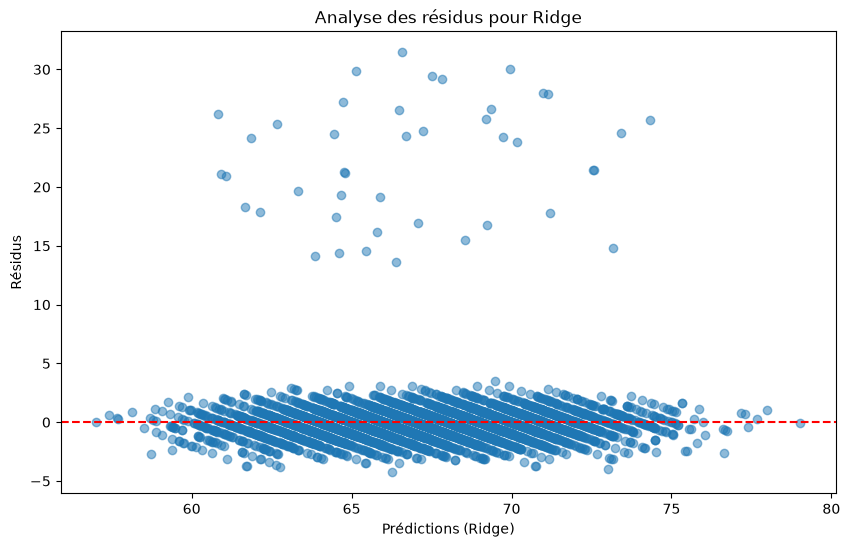

In [95]:
import matplotlib.pyplot as plt

# Prédictions sur l'ensemble d'entraînement (pour analyse)

ridge_best = search.best_estimator_

y_pred = ridge_best.predict(X_train_final)

# Calcul des résidus

residus = y_train - y_pred

# Plot

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residus, alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Prédictions (Ridge)")
plt.ylabel("Résidus")
plt.title("Analyse des résidus pour Ridge")
plt.show()

In [96]:
import joblib
joblib.dump(search.best_estimator_, "ridge_model_final.joblib")

['ridge_model_final.joblib']

In [97]:
model_loaded = joblib.load("ridge_model_final.joblib")
y_pred_loaded = model_loaded.predict(X_train_final)

In [ ]:
# 1. Charger le pipeline complet (déjà fait)
model_loaded = joblib.load("ridge_model_final.joblib")

# 2. Prédire sur le TEST SET, avec les 6 features finales, jamais touché avant
X_test_final = X_test[final_features]
y_pred_test = model_loaded.predict(X_test_final)

# 3. Calculer les métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test MAE  : {mae_test:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")

Test MAE  : 0.9533
Test RMSE : 4.1513
Test R²   : 0.7063


In [99]:
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print(f"Test MAE  : {mae_test:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")

Test MAE  : 0.9533
Test MSE  : 4.1513
Test RMSE : 2.0375
Test R²   : 0.7063


In [100]:
# ============================================
# ANALYSE DES ERREURS DU MODÈLE
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# 1. Calcul des résidus
residuals = y_test - y_pred_test

print("=== STATISTIQUES DES RÉSIDUS ===")
print(f"Moyenne       : {residuals.mean():.4f}")
print(f"Minimum       : {residuals.min():.4f}")
print(f"Maximum       : {residuals.max():.4f}")
print(f"Écart-type    : {residuals.std():.4f}")

=== STATISTIQUES DES RÉSIDUS ===
Moyenne       : -0.0145
Minimum       : -3.4120
Maximum       : 27.6208
Écart-type    : 2.0382


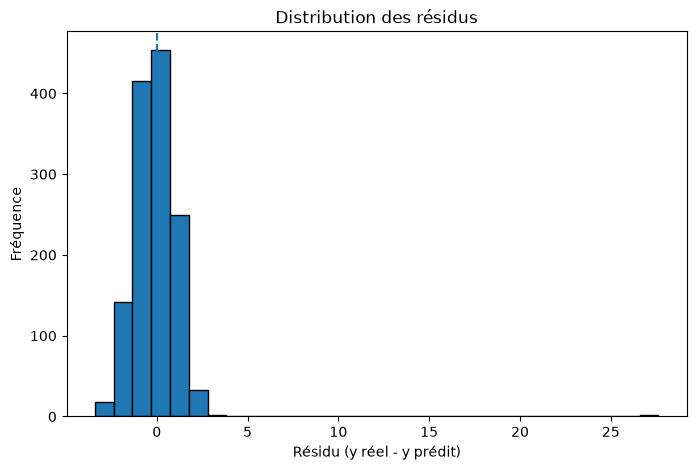

In [101]:
# 2. Distribution des résidus

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribution des résidus")
plt.xlabel("Résidu (y réel - y prédit)")
plt.ylabel("Fréquence")
plt.show()

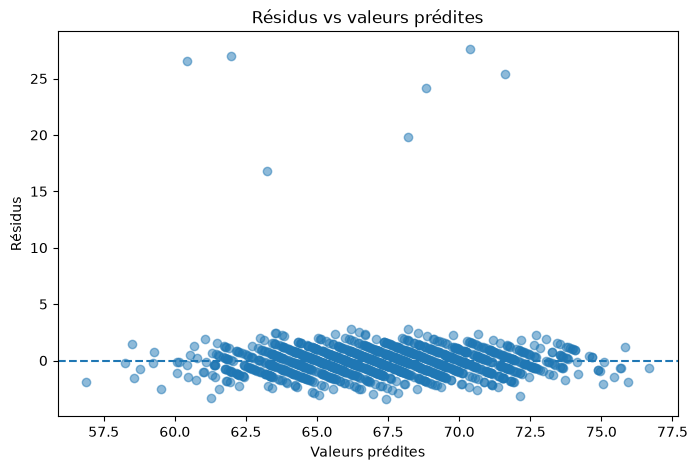

In [102]:
# 3. Résidus vs valeurs prédites

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Résidus vs valeurs prédites")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.show()

In [103]:
# 4. Les 10 plus grosses erreurs

worst_idx = residuals.abs().sort_values(ascending=False).head(10).index

worst_predictions = X_test.loc[worst_idx, [
    "Attendance",
    "Hours_Studied",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Access_to_Resources",
    "Parental_Involvement"
]].copy()

worst_predictions["Score_Réel"] = y_test.loc[worst_idx]
worst_predictions["Score_Prédit"] = y_pred_test[
    y_test.index.get_indexer(worst_idx)
]
worst_predictions["Résidu"] = residuals.loc[worst_idx]
worst_predictions["Erreur_Absolue"] = residuals.loc[worst_idx].abs()

worst_predictions = worst_predictions.sort_values(
    "Erreur_Absolue",
    ascending=False
)

worst_predictions

,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Access_to_Resources,Parental_Involvement,Score_Réel,Score_Prédit,Résidu,Erreur_Absolue
4192,90,28,91,0,Medium,Low,98,70.379230,27.620770,27.620770
217,70,19,54,0,Low,Medium,89,61.988501,27.011499,27.011499
2687,71,11,55,1,Medium,Low,87,60.416453,26.583547,26.583547
5966,99,25,77,0,Medium,Medium,97,71.627045,25.372955,25.372955
4531,69,26,95,0,High,High,93,68.835177,24.164823,24.164823
2513,86,18,60,2,Medium,High,88,68.212778,19.787222,19.787222
5989,61,18,91,3,Low,Medium,80,63.230926,16.769074,16.769074
5760,86,20,94,2,Low,Low,64,67.411955,-3.411955,3.411955
5198,60,15,63,0,Medium,High,58,61.282981,-3.282981,3.282981
3708,90,23,95,2,Medium,High,69,72.155646,-3.155646,3.155646


STATISTIQUES DES RÉSIDUS
Moyenne        : -0.0145
Médiane        : -0.1304
Minimum        : -3.4120
Maximum        : 27.6208
Écart-type     : 2.0382

Quantiles :
0.01   -2.513836
0.05   -1.799694
0.25   -0.846312
0.50   -0.130399
0.75    0.582717
0.95    1.552625
0.99    2.362197
Name: Exam_Score, dtype: float64


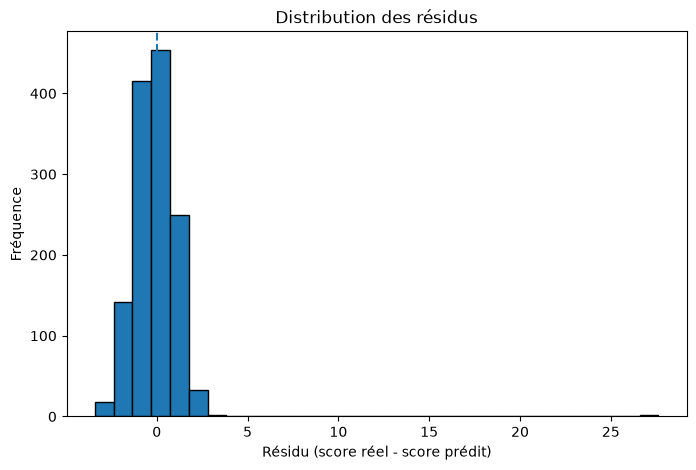

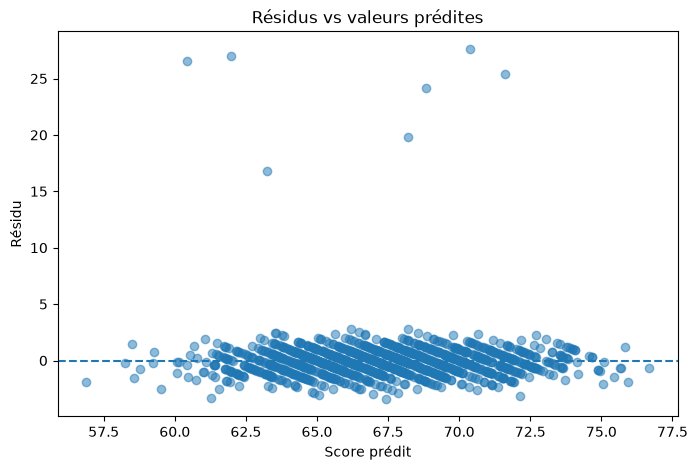


ERREURS ABSOLUES
Erreur absolue moyenne : 0.9533
Erreur absolue médiane : 0.7305
Erreur absolue max     : 27.6208

TOP 10 DES PLUS GROSSES ERREURS


,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Access_to_Resources,Parental_Involvement,Score_Réel,Score_Prédit,Résidu,Erreur_Absolue
4192,90,28,91,0,Medium,Low,98,70.379230,27.620770,27.620770
217,70,19,54,0,Low,Medium,89,61.988501,27.011499,27.011499
2687,71,11,55,1,Medium,Low,87,60.416453,26.583547,26.583547
5966,99,25,77,0,Medium,Medium,97,71.627045,25.372955,25.372955
4531,69,26,95,0,High,High,93,68.835177,24.164823,24.164823
2513,86,18,60,2,Medium,High,88,68.212778,19.787222,19.787222
5989,61,18,91,3,Low,Medium,80,63.230926,16.769074,16.769074
5760,86,20,94,2,Low,Low,64,67.411955,-3.411955,3.411955
5198,60,15,63,0,Medium,High,58,61.282981,-3.282981,3.282981
3708,90,23,95,2,Medium,High,69,72.155646,-3.155646,3.155646



RÉPARTITION DES ERREURS
Erreur >  1 points :  451 observations (34.11%)
Erreur >  2 points :   69 observations (5.22%)
Erreur >  3 points :   11 observations (0.83%)
Erreur >  5 points :    7 observations (0.53%)
Erreur > 10 points :    7 observations (0.53%)
Erreur > 15 points :    7 observations (0.53%)
Erreur > 20 points :    5 observations (0.38%)


In [104]:
# ============================================================
# ANALYSE APPROFONDIE DES RÉSIDUS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Calcul des résidus
# ------------------------------------------------------------

residuals = y_test - y_pred_test

print("=" * 60)
print("STATISTIQUES DES RÉSIDUS")
print("=" * 60)

print(f"Moyenne        : {residuals.mean():.4f}")
print(f"Médiane        : {residuals.median():.4f}")
print(f"Minimum        : {residuals.min():.4f}")
print(f"Maximum        : {residuals.max():.4f}")
print(f"Écart-type     : {residuals.std():.4f}")

print("\nQuantiles :")
print(residuals.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))


# ------------------------------------------------------------
# 2. Distribution des résidus
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution des résidus")
plt.xlabel("Résidu (score réel - score prédit)")
plt.ylabel("Fréquence")

plt.show()


# ------------------------------------------------------------
# 3. Résidus vs valeurs prédites
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_test,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Résidus vs valeurs prédites")
plt.xlabel("Score prédit")
plt.ylabel("Résidu")

plt.show()


# ------------------------------------------------------------
# 4. Analyse des erreurs absolues
# ------------------------------------------------------------

absolute_errors = residuals.abs()

print("\n" + "=" * 60)
print("ERREURS ABSOLUES")
print("=" * 60)

print(f"Erreur absolue moyenne : {absolute_errors.mean():.4f}")
print(f"Erreur absolue médiane : {absolute_errors.median():.4f}")
print(f"Erreur absolue max     : {absolute_errors.max():.4f}")


# ------------------------------------------------------------
# 5. Les 10 plus grosses erreurs
# ------------------------------------------------------------

worst_idx = (
    absolute_errors
    .sort_values(ascending=False)
    .head(10)
    .index
)

worst_predictions = X_test.loc[
    worst_idx,
    [
        "Attendance",
        "Hours_Studied",
        "Previous_Scores",
        "Tutoring_Sessions",
        "Access_to_Resources",
        "Parental_Involvement"
    ]
].copy()

worst_predictions["Score_Réel"] = y_test.loc[worst_idx]

worst_predictions["Score_Prédit"] = (
    pd.Series(
        y_pred_test,
        index=y_test.index
    ).loc[worst_idx]
)

worst_predictions["Résidu"] = (
    residuals.loc[worst_idx]
)

worst_predictions["Erreur_Absolue"] = (
    absolute_errors.loc[worst_idx]
)

worst_predictions = worst_predictions.sort_values(
    "Erreur_Absolue",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 10 DES PLUS GROSSES ERREURS")
print("=" * 60)

display(worst_predictions)


# ------------------------------------------------------------
# 6. Combien d'erreurs dépassent certains seuils ?
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RÉPARTITION DES ERREURS")
print("=" * 60)

for threshold in [1, 2, 3, 5, 10, 15, 20]:
    count = (absolute_errors > threshold).sum()
    percentage = count / len(absolute_errors) * 100

    print(
        f"Erreur > {threshold:2d} points : "
        f"{count:4d} observations "
        f"({percentage:.2f}%)"
    )

In [105]:
# ============================================================
# VALIDATION FINALE DU MODÈLE — STUDENT PERFORMANCE PREDICTOR
# ============================================================

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Charger le modèle final
# ------------------------------------------------------------

model_final = joblib.load("ridge_model_final.joblib")

# ------------------------------------------------------------
# 2. Préparer les données de test
# ------------------------------------------------------------

X_test_final = X_test[final_features]

# ------------------------------------------------------------
# 3. Générer les prédictions finales
# ------------------------------------------------------------

y_pred_final = model_final.predict(X_test_final)

# ------------------------------------------------------------
# 4. Calcul des métriques finales
# ------------------------------------------------------------

mae_final = mean_absolute_error(y_test, y_pred_final)

mse_final = mean_squared_error(y_test, y_pred_final)

rmse_final = np.sqrt(mse_final)

r2_final = r2_score(y_test, y_pred_final)

# ------------------------------------------------------------
# 5. Vérification des prédictions
# ------------------------------------------------------------

print("=" * 65)
print("       VALIDATION FINALE — STUDENT PERFORMANCE PREDICTOR")
print("=" * 65)

print("\n📌 FEATURES FINALES")
print("-" * 65)

for feature in final_features:
    print(f"✓ {feature}")

print("\n📊 MÉTRIQUES SUR LE TEST SET")
print("-" * 65)

print(f"MAE  : {mae_final:.4f}")
print(f"MSE  : {mse_final:.4f}")
print(f"RMSE : {rmse_final:.4f}")
print(f"R²   : {r2_final:.4f}")

print("\n📦 INFORMATIONS DU TEST SET")
print("-" * 65)

print(f"Nombre d'observations : {len(y_test)}")
print(f"Score réel moyen      : {y_test.mean():.2f}")
print(f"Score prédit moyen    : {y_pred_final.mean():.2f}")

print("\n🔍 CONTRÔLES")
print("-" * 65)

print(f"NaN dans prédictions : {np.isnan(y_pred_final).sum()}")
print(f"Min prédiction       : {y_pred_final.min():.2f}")
print(f"Max prédiction       : {y_pred_final.max():.2f}")

print("\n💾 MODÈLE")
print("-" * 65)

print("✓ Pipeline final chargé avec succès")
print("✓ Preprocessing intégré au pipeline")
print("✓ Modèle prêt pour intégration backend")

print("\n" + "=" * 65)
print("                 PHASE ML TERMINÉE ✅")
print("=" * 65)

       VALIDATION FINALE — STUDENT PERFORMANCE PREDICTOR

📌 FEATURES FINALES
-----------------------------------------------------------------
✓ Attendance
✓ Hours_Studied
✓ Previous_Scores
✓ Tutoring_Sessions
✓ Access_to_Resources
✓ Parental_Involvement

📊 MÉTRIQUES SUR LE TEST SET
-----------------------------------------------------------------
MAE  : 0.9533
MSE  : 4.1513
RMSE : 2.0375
R²   : 0.7063

📦 INFORMATIONS DU TEST SET
-----------------------------------------------------------------
Nombre d'observations : 1322
Score réel moyen      : 67.32
Score prédit moyen    : 67.33

🔍 CONTRÔLES
-----------------------------------------------------------------
NaN dans prédictions : 0
Min prédiction       : 56.87
Max prédiction       : 76.69

💾 MODÈLE
-----------------------------------------------------------------
✓ Pipeline final chargé avec succès
✓ Preprocessing intégré au pipeline
✓ Modèle prêt pour intégration backend

                 PHASE ML TERMINÉE ✅


In [106]:
print("TEST")
print(type(X_test_final))
print(X_test_final.shape)
print(type(model_loaded))

TEST
<class 'pandas.DataFrame'>
(1322, 6)
<class 'sklearn.pipeline.Pipeline'>


In [4]:
import json
import urllib.request
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

FEATURES = [
    "Attendance",
    "Hours_Studied",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Access_to_Resources",
    "Parental_Involvement",
]

# Même dataset et même séparation que dans le notebook
data = pd.read_csv("../data/SPP.csv")

X = data.drop(columns=["Exam_Score"])
y = data["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Même sélection que X_test_final dans le notebook
X_test_final = X_test[FEATURES]

# Même pipeline que celui sauvegardé par le notebook
pipeline = joblib.load("ridge_model_final.joblib")

# Trois observations réelles du test set
observations = X_test_final.iloc[:3]

for index, row in observations.iterrows():
    notebook_raw = float(
        pipeline.predict(pd.DataFrame([row], columns=FEATURES))[0]
    )

    notebook_clipped = float(np.clip(notebook_raw, 0, 100))
    notebook_rounded = round(notebook_clipped, 2)

    payload = {}
    for feature in FEATURES:
        value = row[feature]

        if isinstance(value, (np.integer, int)):
            payload[feature] = int(value)
        elif isinstance(value, (np.floating, float)):
            payload[feature] = float(value)
        else:
            payload[feature] = value

    request = urllib.request.Request(
        "http://127.0.0.1:8000/predict",
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
        method="POST",
    )

    with urllib.request.urlopen(request) as response:
        api_body = json.loads(response.read())

    api_prediction = float(api_body["predicted_score"])

    print("=" * 70)
    print(f"Index test set : {index}")
    print("Valeurs envoyées :")
    print(json.dumps(payload, indent=2))
    print(f"Notebook brut    : {notebook_raw:.12f}")
    print(f"Notebook clipped : {notebook_clipped:.12f}")
    print(f"Notebook arrondi : {notebook_rounded:.2f}")
    print(f"API              : {api_prediction:.2f}")
    print(
        f"Différence brute notebook/API : "
        f"{api_prediction - notebook_raw:.12f}"
    )
    print(
        f"Différence après arrondi      : "
        f"{api_prediction - notebook_rounded:.12f}"
    )

    assert api_prediction == notebook_rounded

print("=" * 70)
print("PARITÉ CONFIRMÉE")


Index test set : 743
Valeurs envoyées :
{
  "Attendance": 71,
  "Hours_Studied": 20,
  "Previous_Scores": 87,
  "Tutoring_Sessions": 1,
  "Access_to_Resources": "Low",
  "Parental_Involvement": "Medium"
}
Notebook brut    : 64.584416703323
Notebook clipped : 64.584416703323
Notebook arrondi : 64.58
API              : 64.58
Différence brute notebook/API : -0.004416703323
Différence après arrondi      : 0.000000000000
Index test set : 5551
Valeurs envoyées :
{
  "Attendance": 71,
  "Hours_Studied": 22,
  "Previous_Scores": 98,
  "Tutoring_Sessions": 2,
  "Access_to_Resources": "Low",
  "Parental_Involvement": "Medium"
}
Notebook brut    : 66.211774906403
Notebook clipped : 66.211774906403
Notebook arrondi : 66.21
API              : 66.21
Différence brute notebook/API : -0.001774906403
Différence après arrondi      : 0.000000000000
Index test set : 3442
Valeurs envoyées :
{
  "Attendance": 91,
  "Hours_Studied": 21,
  "Previous_Scores": 53,
  "Tutoring_Sessions": 1,
  "Access_to_Resources